# Clasificación de Paisajes Aéreos mediante Vision Transformer

#### Enlace al video: https://drive.google.com/drive/folders/1Qk974sOFj8la6fRWXQlx8ls8EeZxG510?usp=sharing

## Introducción

En este proyecto se desarrolla un modelo de clasificación de imágenes utilizando una arquitectura
Vision Transformer (ViT) implementada con PyTorch.

Para el entrenamiento se utilizará el dataset **Skyview – An Aerial Landscape Dataset**, compuesto
por imágenes aéreas pertenecientes a 15 categorías diferentes de paisajes.

A diferencia de una Red Neuronal Convolucional (CNN), el Vision Transformer representa la imagen
como una secuencia de pequeños fragmentos o *patches* y utiliza el mecanismo de
**Multi-Head Self-Attention** para aprender relaciones entre las diferentes regiones de la imagen.

Durante el desarrollo se aplicarán técnicas de optimización, regularización y buenas prácticas
de entrenamiento, manteniendo un procedimiento comparable al utilizado previamente con la CNN.

Entre las técnicas utilizadas se encuentran:

- Normalización de imágenes.
- Data Augmentation en el conjunto de entrenamiento.
- División del dataset en entrenamiento, validación y prueba.
- Multi-Head Self-Attention.
- Positional Embedding.
- Conexiones residuales.
- Layer Normalization.
- Feed-Forward Network.
- Optimizador Adam.
- Learning Rate Scheduler.
- Early Stopping.
- Guardado del mejor modelo.

Finalmente, el rendimiento del Vision Transformer será evaluado mediante diferentes métricas de
clasificación y comparado con los resultados obtenidos por la CNN sobre el mismo dataset.

El objetivo principal es determinar la efectividad de una arquitectura basada en Transformers para
la clasificación de imágenes aéreas y analizar sus diferencias respecto a una arquitectura CNN.

## 2. Librerías y configuración

En esta sección se importan las librerías necesarias para trabajar con el dataset,
realizar las transformaciones de las imágenes, construir la arquitectura Vision Transformer,
entrenar el modelo y evaluar sus resultados.

Se utilizarán principalmente PyTorch y Torchvision para la construcción y entrenamiento
del modelo, mientras que NumPy, Matplotlib, Seaborn y Scikit-learn serán utilizados para
la exploración, visualización y evaluación del modelo.

In [ ]:
# Librerías generales

import os
import random
import copy
import time

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms
from torchvision.io import read_image

# Scikit-learn

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

from sklearn.preprocessing import label_binarize

### Configuración del dispositivo

El entrenamiento de modelos de Deep Learning puede acelerarse utilizando una GPU.

Por este motivo se comprobará automáticamente si existe una GPU CUDA disponible.
Si no existe, se utilizará CPU.

También se establecerá una semilla aleatoria para favorecer la reproducibilidad
de los experimentos.

In [ ]:
# Reproducibilidad

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# Dispositivo

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Dispositivo utilizado:", device)

Dispositivo utilizado: cpu


### Configuración del Vision Transformer

A continuación se definen los principales hiperparámetros de la arquitectura.

La imagen será redimensionada a 224×224 píxeles y se dividirá en patches de 16×16 píxeles.
Esto produce:

    224 / 16 = 14

patches por dimensión y, por tanto:

    14 × 14 = 196 patches

Cada patch RGB contiene:

    16 × 16 × 3 = 768

valores.

Estos valores serán proyectados a un espacio de representación de dimensión 256.

Se utilizarán 8 cabezas de atención, por lo que cada cabeza trabajará con:

    256 / 8 = 32

dimensiones.

In [ ]:
# Configuración del modelo

IMG_SIZE = 224
PATCH_SIZE = 16

IN_CHANNELS = 3

NUM_PATCHES = (IMG_SIZE // PATCH_SIZE) ** 2

PATCH_DIM = PATCH_SIZE * PATCH_SIZE * IN_CHANNELS

EMBED_DIM = 256

NUM_HEADS = 8

HEAD_DIM = EMBED_DIM // NUM_HEADS

NUM_LAYERS = 4

MLP_DIM = 1024

NUM_CLASSES = 15


# Configuración del entrenamiento

BATCH_SIZE = 32

LEARNING_RATE = 5e-4

WEIGHT_DECAY = 1e-4

EPOCHS = 50

PATIENCE = 10


# Mostrar configuración

print("================================")
print("Configuración Vision Transformer")
print("================================")

print(f"Tamaño de entrada      : {IMG_SIZE} x {IMG_SIZE} x {IN_CHANNELS}")
print(f"Tamaño del patch       : {PATCH_SIZE} x {PATCH_SIZE}")
print(f"Número de patches      : {NUM_PATCHES}")
print(f"Valores por patch      : {PATCH_DIM}")
print(f"Embedding dimension    : {EMBED_DIM}")
print(f"Número de heads        : {NUM_HEADS}")
print(f"Dimensión por head     : {HEAD_DIM}")
print(f"Número de bloques      : {NUM_LAYERS}")
print(f"Dimensión FFN          : {MLP_DIM}")
print(f"Número de clases       : {NUM_CLASSES}")
print(f"Batch Size             : {BATCH_SIZE}")
print(f"Learning Rate          : {LEARNING_RATE}")
print(f"Weight Decay           : {WEIGHT_DECAY}")
print(f"Epochs máximas         : {EPOCHS}")
print(f"Early Stopping Patience: {PATIENCE}")

Configuración Vision Transformer
Tamaño de entrada      : 224 x 224 x 3
Tamaño del patch       : 16 x 16
Número de patches      : 196
Valores por patch      : 768
Embedding dimension    : 256
Número de heads        : 8
Dimensión por head     : 32
Número de bloques      : 4
Dimensión FFN          : 1024
Número de clases       : 15
Batch Size             : 32
Learning Rate          : 0.0005
Weight Decay           : 0.0001
Epochs máximas         : 50
Early Stopping Patience: 10


In [4]:
assert IMG_SIZE % PATCH_SIZE == 0
assert EMBED_DIM % NUM_HEADS == 0

print("\nVerificaciones:")
print(f"✓ {IMG_SIZE} es divisible entre {PATCH_SIZE}")
print(f"✓ {EMBED_DIM} es divisible entre {NUM_HEADS}")
print(f"✓ Número de patches: {NUM_PATCHES}")
print(f"✓ Dimensión por head: {HEAD_DIM}")


Verificaciones:
✓ 224 es divisible entre 16
✓ 256 es divisible entre 8
✓ Número de patches: 196
✓ Dimensión por head: 32


# 3. Dataset

Para este proyecto se utilizará el mismo dataset empleado en el laboratorio
de redes convolucionales, con el objetivo de realizar una comparación justa
entre la CNN y el Vision Transformer.

El dataset utilizado es:

**Skyview – An Aerial Landscape Dataset**

El conjunto contiene imágenes aéreas pertenecientes a diferentes categorías
de paisajes.

Características principales:

- 12 000 imágenes.
- 15 clases.
- 800 imágenes por clase.
- Resolución original de 256 × 256 píxeles.

Para nuestro Vision Transformer, las imágenes serán posteriormente redimensionadas
a 224 × 224 píxeles.

Esta resolución permitirá dividir cada imagen en patches de 16 × 16 píxeles,
obteniendo:

    224 / 16 = 14

patches por dimensión y:

    14 × 14 = 196

patches por imagen.

### Ruta del dataset

A continuación se define la ruta donde se encuentra almacenado el dataset.

La estructura esperada es una carpeta principal que contiene una subcarpeta
para cada clase.

In [5]:
# Ruta principal del dataset
DATASET_DIR = "Dataset/dataset/archive/Aerial_Landscapes"

## 4.1 Número de clases

El primer paso consiste en identificar las categorías presentes en el dataset.

Cada carpeta representa una clase diferente. Por tanto, podemos obtener las
clases leyendo los directorios existentes dentro de la carpeta principal.

In [6]:
# Obtener las clases a partir de las carpetas
classes = sorted([
    folder for folder in os.listdir(DATASET_DIR)
    if os.path.isdir(os.path.join(DATASET_DIR, folder))
])

NUM_CLASSES_DATASET = len(classes)

print("Número de clases:", NUM_CLASSES_DATASET)
print("\nClases:")

for i, class_name in enumerate(classes):
    print(f"{i}: {class_name}")

Número de clases: 15

Clases:
0: Agriculture
1: Airport
2: Beach
3: City
4: Desert
5: Forest
6: Grassland
7: Highway
8: Lake
9: Mountain
10: Parking
11: Port
12: Railway
13: Residential
14: River


### Interpretación

El dataset contiene 15 clases, por lo que el problema corresponde a una
clasificación multiclase.

Este valor será utilizado posteriormente en la salida del modelo:

    Linear(EMBED_DIM, NUM_CLASSES)

Por tanto, el Vision Transformer producirá 15 logits para cada imagen.

## 4.2 Imágenes por clase

A continuación se contará la cantidad de imágenes disponibles en cada categoría.

Esta comprobación permite conocer la distribución del dataset y detectar
posibles diferencias importantes entre clases.

In [7]:
# Extensiones de imagen permitidas
IMAGE_EXTENSIONS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
)

class_counts = {}

for class_name in classes:

    class_path = os.path.join(DATASET_DIR, class_name)

    count = sum(
        1
        for file_name in os.listdir(class_path)
        if file_name.lower().endswith(IMAGE_EXTENSIONS)
    )

    class_counts[class_name] = count


# Convertir a DataFrame
class_distribution = pd.DataFrame(
    {
        "Clase": list(class_counts.keys()),
        "Cantidad": list(class_counts.values())
    }
)

class_distribution

,Clase,Cantidad
0,Agriculture,800
1,Airport,800
2,Beach,800
3,City,800
4,Desert,800
5,Forest,800
6,Grassland,800
7,Highway,800
8,Lake,800
9,Mountain,800


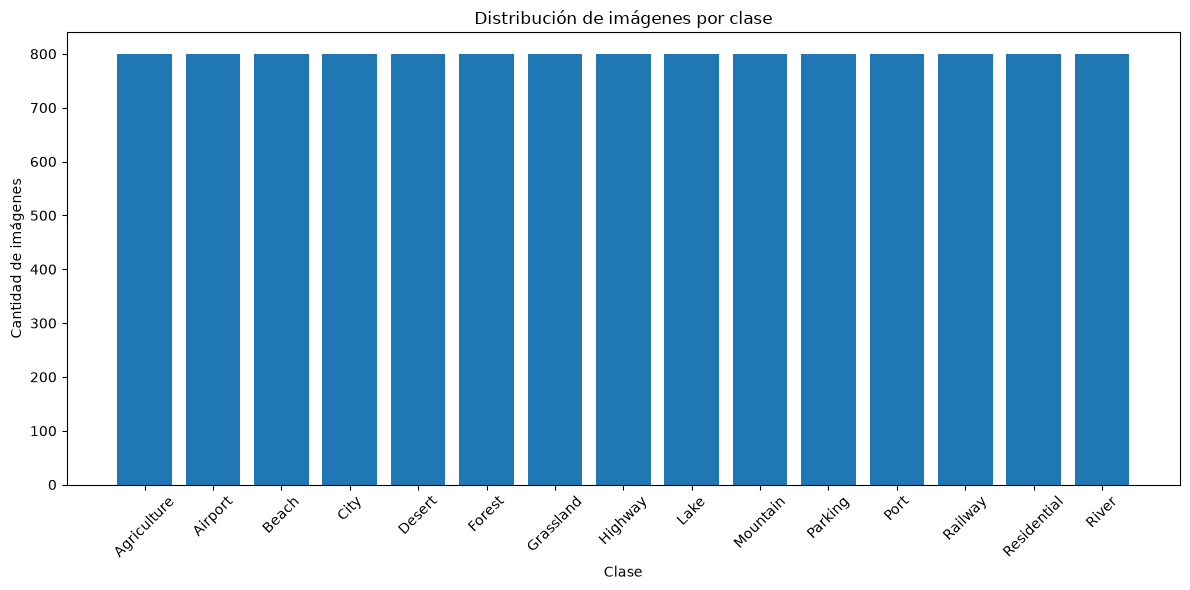

In [8]:
plt.figure(figsize=(12, 6))

plt.bar(
    class_distribution["Clase"],
    class_distribution["Cantidad"]
)

plt.xlabel("Clase")
plt.ylabel("Cantidad de imágenes")
plt.title("Distribución de imágenes por clase")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Interpretación

La distribución de imágenes permite comprobar si las clases se encuentran
aproximadamente balanceadas.

De acuerdo con la descripción del dataset utilizada en el Laboratorio 2,
se dispone de aproximadamente 800 imágenes por clase, para un total de
12 000 imágenes distribuidas en 15 categorías.

Una distribución equilibrada resulta favorable para el entrenamiento,
ya que evita que el modelo esté excesivamente influenciado por una clase
con una cantidad mucho mayor de ejemplos.

## 4.3 Visualización de imágenes

Se visualizarán ejemplos pertenecientes a diferentes categorías del dataset.

Esta exploración permite comprobar visualmente que las imágenes fueron
cargadas correctamente y observar algunas de las características que el
modelo deberá aprender para distinguir entre las diferentes clases.

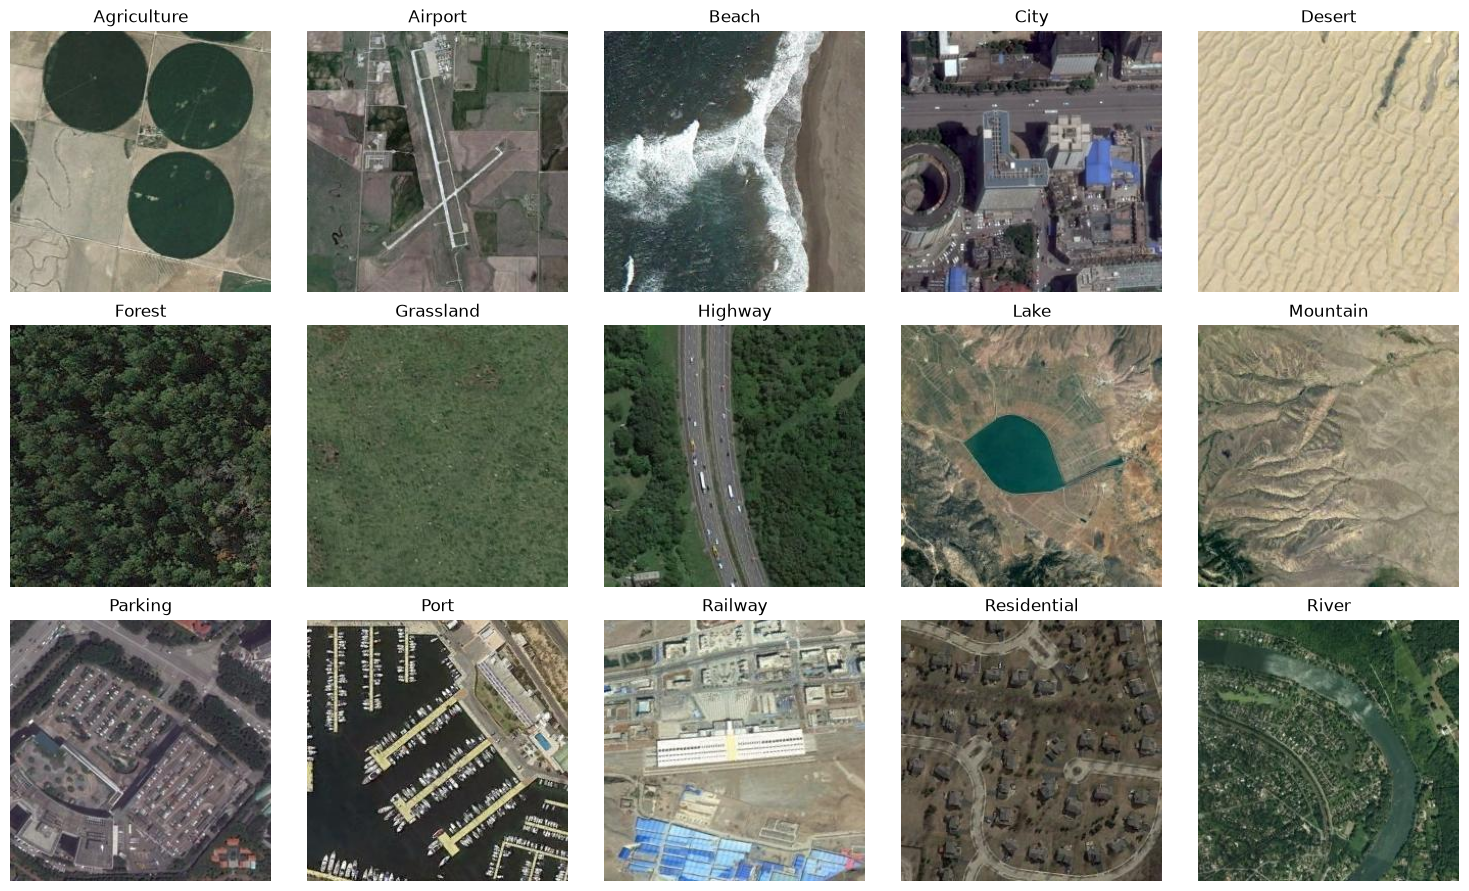

In [9]:
# Mostrar una imagen representativa de cada clase

fig, axes = plt.subplots(
    3,
    5,
    figsize=(15, 9)
)

axes = axes.flatten()

for idx, class_name in enumerate(classes):

    class_path = os.path.join(DATASET_DIR, class_name)

    image_files = [
        file_name
        for file_name in os.listdir(class_path)
        if file_name.lower().endswith(IMAGE_EXTENSIONS)
    ]

    image_path = os.path.join(
        class_path,
        image_files[0]
    )

    image = plt.imread(image_path)

    axes[idx].imshow(image)
    axes[idx].set_title(class_name)
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

## 4.4 Resoluciones

Antes de definir las transformaciones de entrada es necesario conocer las
resoluciones originales de las imágenes.

El dataset utilizado en el Laboratorio 2 tiene imágenes de 256 × 256 píxeles.

Posteriormente todas las imágenes serán redimensionadas a 224 × 224 para
utilizarlas como entrada del Vision Transformer.

In [10]:
from PIL import Image

# Analizar las resoluciones de una muestra de imágenes
resolutions = []

MAX_IMAGES_TO_CHECK = 1000

checked = 0

for class_name in classes:

    class_path = os.path.join(DATASET_DIR, class_name)

    for file_name in os.listdir(class_path):

        if not file_name.lower().endswith(IMAGE_EXTENSIONS):
            continue

        image_path = os.path.join(
            class_path,
            file_name
        )

        try:
            with Image.open(image_path) as image:
                resolutions.append(image.size)

        except Exception:
            pass

        checked += 1

        if checked >= MAX_IMAGES_TO_CHECK:
            break

    if checked >= MAX_IMAGES_TO_CHECK:
        break


resolution_counts = pd.Series(resolutions).value_counts()

print("Resoluciones encontradas:")
print(resolution_counts)

Resoluciones encontradas:
(256, 256)    1000
Name: count, dtype: int64


## 5.1 Rutas y etiquetas

Para entrenar un modelo de clasificación necesitamos asociar cada imagen
con la clase a la que pertenece.

Para ello se construirá una lista que contenga:

- La ruta de cada imagen.
- La etiqueta correspondiente a su clase.

La etiqueta inicialmente estará representada mediante el nombre de la carpeta
a la que pertenece la imagen.

In [ ]:
# Construcción de rutas y etiquetas

image_paths = []
image_labels = []

for class_idx, class_name in enumerate(classes):

    class_path = os.path.join(DATASET_DIR, class_name)

    for file_name in os.listdir(class_path):

        if not file_name.lower().endswith(IMAGE_EXTENSIONS):
            continue

        image_path = os.path.join(
            class_path,
            file_name
        )

        image_paths.append(image_path)
        image_labels.append(class_idx)


print("Número total de imágenes:", len(image_paths))
print("Número total de etiquetas:", len(image_labels))

Número total de imágenes: 12000
Número total de etiquetas: 12000


## 5.2 Codificación de clases

Los modelos de clasificación no trabajan directamente con nombres de clases
como texto. Por ello, cada categoría será representada mediante un valor
entero.

La codificación tendrá la forma:

    nombre de clase → índice numérico

Estos índices serán utilizados posteriormente como objetivos (*targets*)
durante el entrenamiento con CrossEntropyLoss.

In [ ]:
# Codificación de clases

class_to_idx = {
    class_name: idx
    for idx, class_name in enumerate(classes)
}

idx_to_class = {
    idx: class_name
    for class_name, idx in class_to_idx.items()
}


print("Mapeo de clases:\n")

for class_name, idx in class_to_idx.items():
    print(f"{idx:2d} → {class_name}")

Mapeo de clases:

 0 → Agriculture
 1 → Airport
 2 → Beach
 3 → City
 4 → Desert
 5 → Forest
 6 → Grassland
 7 → Highway
 8 → Lake
 9 → Mountain
10 → Parking
11 → Port
12 → Railway
13 → Residential
14 → River


## 5.3 División 70/15/15

El dataset será dividido en tres subconjuntos:

- 70% para entrenamiento.
- 15% para validación.
- 15% para prueba.

El conjunto de entrenamiento será utilizado para actualizar los parámetros
del modelo.

El conjunto de validación será utilizado durante el entrenamiento para
evaluar la capacidad de generalización y controlar el Early Stopping.

El conjunto de prueba se mantendrá separado y será utilizado únicamente
para la evaluación final del modelo.

In [ ]:
# División Train / Temp

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths,
    image_labels,
    test_size=0.30,
    random_state=SEED,
    stratify=image_labels
)

In [ ]:
# División Validation / Test

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_labels
)

In [15]:
print("Train:")
print(f"  Imágenes: {len(train_paths)}")

print("\nValidation:")
print(f"  Imágenes: {len(val_paths)}")

print("\nTest:")
print(f"  Imágenes: {len(test_paths)}")

print("\nTotal:")
print(f"  Imágenes: {len(image_paths)}")

Train:
  Imágenes: 8400

Validation:
  Imágenes: 1800

Test:
  Imágenes: 1800

Total:
  Imágenes: 12000


## 5.4 Dataset personalizado

Se implementará una clase personalizada basada en `torch.utils.data.Dataset`.

Esta clase será responsable de:

1. Almacenar las rutas y etiquetas.
2. Cargar una imagen cuando sea solicitada.
3. Aplicar las transformaciones correspondientes.
4. Devolver la imagen y su etiqueta.

La clase permitirá utilizar el mismo mecanismo tanto para entrenamiento,
validación como para prueba, cambiando únicamente las transformaciones.

In [ ]:
# Dataset personalizado

class SkyviewDataset(Dataset):

    def __init__(self, image_paths, labels, transform=None):

        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):

        return len(self.image_paths)

    def __getitem__(self, index):

        image_path = self.image_paths[index]
        label = self.labels[index]

        image = Image.open(image_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        return image, label

## 5.5 DataLoaders

Los `DataLoader` permiten entregar las imágenes al modelo en pequeños grupos
denominados *batches*.

En este proyecto se utilizará un `batch size` de 32.

Por tanto, durante el entrenamiento el modelo recibirá tensores con una
estructura:

    [32, 3, 224, 224]

donde:

- 32 corresponde al número de imágenes del batch.
- 3 corresponde a los canales RGB.
- 224 corresponde al alto.
- 224 corresponde al ancho.

Esta será la representación de entrada que posteriormente recibirá nuestro
Vision Transformer.

In [17]:
print("Resumen de las particiones")
print("==========================")

print(f"Train      : {len(train_paths)} imágenes")
print(f"Validation : {len(val_paths)} imágenes")
print(f"Test       : {len(test_paths)} imágenes")
print(f"Total      : {len(image_paths)} imágenes")

Resumen de las particiones
Train      : 8400 imágenes
Validation : 1800 imágenes
Test       : 1800 imágenes
Total      : 12000 imágenes


## 6.1 Transformaciones de entrenamiento

Durante el entrenamiento se aplicarán transformaciones que permitan aumentar
la variedad de imágenes que observa el modelo.

Esto ayuda a reducir el sobreajuste y favorece la capacidad de generalización.

Las imágenes serán:

1. Redimensionadas a 224 × 224.
2. Transformadas mediante operaciones de Data Augmentation.
3. Convertidas a tensores.
4. Normalizadas.

El redimensionamiento a 224 × 224 es necesario porque nuestra arquitectura
Vision Transformer utilizará imágenes que puedan dividirse exactamente en
patches de 16 × 16 píxeles.

In [18]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(
        10,
        fill=(124, 116, 104)
    ),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

## 6.2 Transformaciones de validación/test

Para los conjuntos de validación y prueba no se aplicará Data Augmentation.

Esto permite evaluar el modelo utilizando imágenes procesadas de manera
determinista.

Se realizará únicamente:

- Redimensionamiento.
- Conversión a tensor.
- Normalización.

De esta manera, las métricas obtenidas representan de forma más estable
el comportamiento del modelo sobre datos que no fueron utilizados para
actualizar sus parámetros.

In [ ]:
# Transformaciones de validación/test

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

## 6.3 Prueba de una imagen

Antes de construir los DataLoaders se comprobará el funcionamiento de las
transformaciones sobre una imagen individual.

Se verificará:

- La clase original.
- La resolución original.
- La resolución después del Resize.
- La forma del tensor resultante.
- Los valores mínimos y máximos del tensor.

In [ ]:
# Prueba de una imagen

sample_path = train_paths[0]
sample_label = train_labels[0]

# Cargar imagen original
sample_image = Image.open(sample_path).convert("RGB")

print("Información de la imagen original")
print("=================================")

print("Ruta:", sample_path)
print("Clase:", idx_to_class[sample_label])
print("Resolución:", sample_image.size)


# Aplicar transformación
sample_tensor = train_transform(sample_image)

print("\nInformación después de la transformación")
print("=========================================")

print("Tipo:", type(sample_tensor))
print("Shape:", sample_tensor.shape)
print("Valor mínimo:", sample_tensor.min().item())
print("Valor máximo:", sample_tensor.max().item())

Información de la imagen original
Ruta: Dataset/dataset/archive/Aerial_Landscapes\Airport\740.jpg
Clase: Airport
Resolución: (256, 256)

Información después de la transformación
Tipo: <class 'torch.Tensor'>
Shape: torch.Size([3, 224, 224])
Valor mínimo: -1.7925336360931396
Valor máximo: 2.1694118976593018


## 6.4 Visualización de una imagen transformada

La normalización modifica los valores de los píxeles, por lo que antes de
visualizar una imagen transformada será necesario revertir temporalmente
la normalización.

Esta operación se realiza únicamente para fines de visualización y no
forma parte del procesamiento utilizado por el modelo.

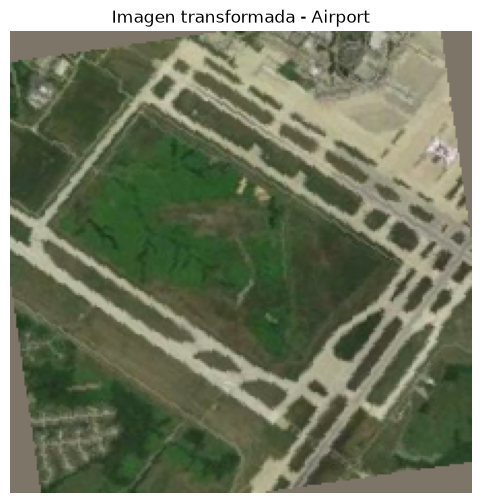

In [ ]:
# Desnormalización para visualizar

mean = torch.tensor(
    [0.485, 0.456, 0.406]
).view(3, 1, 1)

std = torch.tensor(
    [0.229, 0.224, 0.225]
).view(3, 1, 1)


# Desnormalizar
image_to_show = sample_tensor * std + mean

# Limitar valores al rango [0, 1]
image_to_show = torch.clamp(
    image_to_show,
    0,
    1
)

# Convertir de [C,H,W] a [H,W,C]
image_to_show = image_to_show.permute(
    1, 2, 0
)

# Visualizar
plt.figure(figsize=(6, 6))

plt.imshow(image_to_show)

plt.title(
    f"Imagen transformada - {idx_to_class[sample_label]}"
)

plt.axis("off")

plt.show()

### Creación de los conjuntos Dataset

Se crearán tres objetos `SkyviewDataset`:

- `train_dataset`
- `val_dataset`
- `test_dataset`

El conjunto de entrenamiento utilizará Data Augmentation, mientras que
validación y prueba utilizarán únicamente las transformaciones deterministas.

In [ ]:
# Crear los Dataset

train_dataset = SkyviewDataset(
    train_paths,
    train_labels,
    transform=train_transform
)

val_dataset = SkyviewDataset(
    val_paths,
    val_labels,
    transform=test_transform
)

test_dataset = SkyviewDataset(
    test_paths,
    test_labels,
    transform=test_transform
)


print("Datasets creados correctamente")

print(f"Train      : {len(train_dataset)}")
print(f"Validation : {len(val_dataset)}")
print(f"Test       : {len(test_dataset)}")

Datasets creados correctamente
Train      : 8400
Validation : 1800
Test       : 1800


### Creación de los DataLoaders

Los DataLoaders permiten obtener las imágenes en batches durante el
entrenamiento y evaluación.

Se utilizará un `batch_size` de 32.

El entrenamiento utilizará `shuffle=True` para cambiar el orden de las
muestras en cada época.

Los conjuntos de validación y prueba no necesitan mezclar las muestras.

In [23]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

In [ ]:
# Comprobar un batch

images, labels = next(iter(train_loader))

print("Información del batch")
print("=====================")

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

print("\nTipo de images:", images.dtype)
print("Tipo de labels:", labels.dtype)

Información del batch
Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])

Tipo de images: torch.float32
Tipo de labels: torch.int64


In [ ]:
# Verificación final del pipeline

assert images.shape == (
    BATCH_SIZE,
    IN_CHANNELS,
    IMG_SIZE,
    IMG_SIZE
)

assert labels.shape == (BATCH_SIZE,)

print("✓ Pipeline de datos funcionando correctamente")
print(f"✓ Entrada al modelo: {tuple(images.shape)}")
print(f"✓ Etiquetas: {tuple(labels.shape)}")
print("✓ Transformaciones aplicadas correctamente")
print("✓ DataLoader funcionando correctamente")

✓ Pipeline de datos funcionando correctamente
✓ Entrada al modelo: (32, 3, 224, 224)
✓ Etiquetas: (32,)
✓ Transformaciones aplicadas correctamente
✓ DataLoader funcionando correctamente


# 7. Arquitectura Vision Transformer

En esta sección se implementará la arquitectura de un Vision Transformer
(ViT) desde sus componentes fundamentales.

La imagen no será procesada mediante filtros convolucionales. En su lugar,
será convertida en una secuencia de pequeños fragmentos llamados *patches*.

La arquitectura seguirá las siguientes etapas:

    Imagen
       ↓
    Patch Embedding
       ↓
    Positional Embedding
       ↓
    Agregar CLS Token
       ↓
    Transformer Blocks
       ↓
    Classification Head
       ↓
    Predicción

Los principales componentes serán:

- Patch Embedding.
- Positional Embedding.
- Multi-Head Self-Attention.
- Transformer Block.
- Classification Head.

## 7.1 Patch Embedding

Un Transformer trabaja naturalmente con secuencias.

Por ejemplo, en procesamiento de lenguaje podemos tener:

    palabra → token → vector

Sin embargo, una imagen no es inicialmente una secuencia de tokens.

Una imagen RGB de 224 × 224 tiene la forma:

    [3, 224, 224]

Por ello, debemos convertir la imagen en una secuencia.

Para hacerlo, dividiremos la imagen en patches de:

    16 × 16 píxeles

Como:

    224 / 16 = 14

obtenemos:

    14 × 14 = 196 patches

Cada patch contiene tres canales RGB:

    16 × 16 × 3 = 768 valores

Por tanto, inicialmente podemos representar la imagen como:

    [196, 768]

Sin embargo, nuestro Transformer utilizará un espacio de embedding
de dimensión 256.

Por ello cada patch será proyectado:

    768 → 256

obteniendo finalmente:

    [196, 256]

Para un batch de 32 imágenes:

    [32, 196, 256]

### Implementación del Patch Embedding

El primer paso consiste en extraer los patches de cada imagen.

Utilizaremos `torch.unfold` para dividir espacialmente la imagen en
fragmentos de 16 × 16 píxeles.

Posteriormente, cada patch será reorganizado para obtener un vector
de 768 valores.

Finalmente, una capa Linear proyectará estos 768 valores a un embedding
de dimensión 256.

In [26]:
class PatchEmbedding(nn.Module):

    def __init__(
        self,
        img_size=224,
        patch_size=16,
        in_channels=3,
        embed_dim=256
    ):
        super().__init__()

        self.img_size = img_size
        self.patch_size = patch_size

        self.num_patches = (
            img_size // patch_size
        ) ** 2

        self.patch_dim = (
            patch_size
            * patch_size
            * in_channels
        )

        self.projection = nn.Linear(
            self.patch_dim,
            embed_dim
        )

    def forward(self, x):

        # x: [B, C, H, W]

        B, C, H, W = x.shape

        # Extraer patches verticalmente
        x = x.unfold(
            2,
            self.patch_size,
            self.patch_size
        )

        # Extraer patches horizontalmente
        x = x.unfold(
            3,
            self.patch_size,
            self.patch_size
        )

        # [B, C, 14, 14, 16, 16]

        # Reorganizar dimensiones
        x = x.permute(
            0, 2, 3, 1, 4, 5
        )

        # [B, 14, 14, C, 16, 16]

        # Convertir los patches en una secuencia
        x = x.reshape(
            B,
            self.num_patches,
            self.patch_dim
        )

        # [B, 196, 768]

        # Proyectar cada patch
        x = self.projection(x)

        # [B, 196, 256]

        return x

### Prueba del Patch Embedding

Se probará el módulo utilizando un batch real procedente del DataLoader.

La entrada esperada será:

    [32, 3, 224, 224]

y la salida esperada:

    [32, 196, 256]

In [ ]:
# Crear Patch Embedding

patch_embedding = PatchEmbedding(
    img_size=IMG_SIZE,
    patch_size=PATCH_SIZE,
    in_channels=IN_CHANNELS,
    embed_dim=EMBED_DIM
)

patch_embedding = patch_embedding.to(device)


# Probar con un batch

images, labels = next(iter(train_loader))

images = images.to(device)

with torch.no_grad():

    patch_tokens = patch_embedding(images)


print("Entrada:")
print(images.shape)

print("\nSalida:")
print(patch_tokens.shape)

Entrada:
torch.Size([32, 3, 224, 224])

Salida:
torch.Size([32, 196, 256])


## 7.2 Positional Embedding

Después del Patch Embedding tenemos una secuencia de 196 tokens:

    [196, 256]

Cada token representa un patch de la imagen.

Sin embargo, el mecanismo de atención por sí solo no conoce la posición
espacial original de cada patch.

Por ejemplo, debemos poder distinguir entre:

    patch de la esquina superior izquierda

y:

    patch de la esquina inferior derecha

Para proporcionar esta información se añade un embedding posicional.

El embedding posicional tendrá la misma dimensión que los embeddings
de los patches:

    [196, 256]

Cada posición de la secuencia tendrá asociado un vector de 256 valores.

Estos vectores se sumarán elemento a elemento con los embeddings de los
patches.

### CLS Token

Para realizar la clasificación de una imagen se utilizará un token especial
denominado `[CLS]` (classification token).

Este token se coloca al principio de la secuencia.

Antes de agregarlo tenemos:

    [Patch1, Patch2, ..., Patch196]

Después:

    [CLS, Patch1, Patch2, ..., Patch196]

Por tanto, la secuencia pasa de 196 a 197 tokens.

El embedding del `[CLS]` tendrá también dimensión 256.

### Implementación

El módulo recibirá los embeddings de los patches:

    [B, 196, 256]

y realizará dos operaciones:

1. Agregar el `[CLS]` al comienzo de la secuencia.
2. Añadir el positional embedding.

El resultado será:

    [B, 197, 256]

In [28]:
class PositionalEmbedding(nn.Module):

    def __init__(
        self,
        num_patches=196,
        embed_dim=256
    ):
        super().__init__()

        # Token CLS aprendible
        self.cls_token = nn.Parameter(
            torch.zeros(1, 1, embed_dim)
        )

        # Positional embedding
        # +1 por el CLS token
        self.pos_embedding = nn.Parameter(
            torch.zeros(
                1,
                num_patches + 1,
                embed_dim
            )
        )

        # Inicialización
        nn.init.trunc_normal_(
            self.cls_token,
            std=0.02
        )

        nn.init.trunc_normal_(
            self.pos_embedding,
            std=0.02
        )

    def forward(self, x):

        # x: [B, num_patches, embed_dim]

        B = x.shape[0]

        # Expandir CLS para todo el batch
        cls_tokens = self.cls_token.expand(
            B,
            -1,
            -1
        )

        # Agregar CLS al comienzo
        x = torch.cat(
            (cls_tokens, x),
            dim=1
        )

        # Agregar información posicional
        x = x + self.pos_embedding

        return x

### Prueba del CLS Token y Positional Embedding

Se utilizará como entrada el resultado obtenido anteriormente mediante
Patch Embedding.

La entrada será:

    [32, 196, 256]

Después de agregar el CLS token y el positional embedding esperamos:

    [32, 197, 256]

In [ ]:
# Crear Positional Embedding

positional_embedding = PositionalEmbedding(
    num_patches=patch_embedding.num_patches,
    embed_dim=EMBED_DIM
)

positional_embedding = positional_embedding.to(device)


# Aplicar al batch

with torch.no_grad():

    tokens = positional_embedding(
        patch_tokens
    )


print("Patch embeddings:")
print(patch_tokens.shape)

print("\nDespués de CLS + Positional Embedding:")
print(tokens.shape)

Patch embeddings:
torch.Size([32, 196, 256])

Después de CLS + Positional Embedding:
torch.Size([32, 197, 256])


In [30]:
cls_tokens = tokens[:, 0, :]

print("CLS tokens:", cls_tokens.shape)

CLS tokens: torch.Size([32, 256])


## 7.3 Multi-Head Self-Attention

El mecanismo Multi-Head Self-Attention permite que cada token pueda
interactuar con los demás tokens de la secuencia.

En nuestro Vision Transformer, los tokens representan:

- El token `[CLS]`.
- Los 196 patches de la imagen.

Por tanto, nuestra secuencia contiene:

    197 tokens

Cada token tiene una representación de:

    256 dimensiones

La entrada al mecanismo de atención tendrá la forma:

    [B, 197, 256]

donde B representa el tamaño del batch.

Utilizaremos 8 heads.

Como la dimensión del embedding es 256:

    256 / 8 = 32

Cada head trabajará con una dimensión de 32.

### Generación de Queries, Keys y Values

A partir de la entrada X se generan tres representaciones:

    Q = XWq
    K = XWk
    V = XWv

Estas proyecciones son capas lineales aprendibles.

En nuestro caso:

    X → [B, 197, 256]

y cada proyección inicialmente mantiene la dimensión:

    [B, 197, 256]

Posteriormente estas representaciones serán reorganizadas para separar
las 8 heads.

In [31]:
class MultiHeadSelfAttention(nn.Module):

    def __init__(
        self,
        embed_dim=256,
        num_heads=8,
        dropout=0.1
    ):
        super().__init__()

        assert embed_dim % num_heads == 0

        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads

        # Proyecciones de Q, K y V
        self.q_proj = nn.Linear(
            embed_dim,
            embed_dim
        )

        self.k_proj = nn.Linear(
            embed_dim,
            embed_dim
        )

        self.v_proj = nn.Linear(
            embed_dim,
            embed_dim
        )

        # Proyección final
        self.out_proj = nn.Linear(
            embed_dim,
            embed_dim
        )

        self.dropout = nn.Dropout(dropout)

### Separación de las heads

Después de obtener Q, K y V, cada representación tiene:

    [B, 197, 256]

Como utilizamos 8 heads y:

    256 / 8 = 32

cada token tendrá 32 dimensiones por head.

La representación se reorganizará como:

    [B, 197, 8, 32]

y posteriormente:

    [B, 8, 197, 32]

La dimensión correspondiente a las heads queda separada para poder
realizar la atención independientemente en cada una.

In [32]:
def split_heads(self, x):

    B, N, _ = x.shape

    x = x.reshape(
        B,
        N,
        self.num_heads,
        self.head_dim
    )

    x = x.transpose(1, 2)

    return x

### Scaled Dot-Product Attention

Cada head calcula la compatibilidad entre cada token y todos los demás
tokens mediante el producto:

    QKᵀ

En nuestro caso:

    Q  → [B, 8, 197, 32]
    K  → [B, 8, 197, 32]

Al realizar:

    QKᵀ

obtenemos:

    [B, 8, 197, 197]

Cada fila representa un token que está consultando a los 197 tokens
de la secuencia.

Posteriormente se divide por √32 y se aplica Softmax para convertir
los scores en pesos de atención.

In [33]:
class MultiHeadSelfAttention(nn.Module):

    def __init__(
        self,
        embed_dim=256,
        num_heads=8,
        dropout=0.1
    ):
        super().__init__()

        assert embed_dim % num_heads == 0

        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads

        self.q_proj = nn.Linear(
            embed_dim,
            embed_dim
        )

        self.k_proj = nn.Linear(
            embed_dim,
            embed_dim
        )

        self.v_proj = nn.Linear(
            embed_dim,
            embed_dim
        )

        self.out_proj = nn.Linear(
            embed_dim,
            embed_dim
        )

        self.dropout = nn.Dropout(dropout)

    def split_heads(self, x):

        B, N, _ = x.shape

        x = x.reshape(
            B,
            N,
            self.num_heads,
            self.head_dim
        )

        x = x.transpose(1, 2)

        return x

    def forward(self, x):

        B, N, _ = x.shape

        # Q, K, V
        Q = self.q_proj(x)
        K = self.k_proj(x)
        V = self.v_proj(x)

        # Separar heads
        Q = self.split_heads(Q)
        K = self.split_heads(K)
        V = self.split_heads(V)

        # QKᵀ
        scores = torch.matmul(
            Q,
            K.transpose(-2, -1)
        )

        # Escalamiento
        scores = scores / (
            self.head_dim ** 0.5
        )

        # Softmax
        attention_weights = torch.softmax(
            scores,
            dim=-1
        )

        attention_weights = self.dropout(
            attention_weights
        )

        # Atención × V
        context = torch.matmul(
            attention_weights,
            V
        )

        # Unir heads
        context = context.transpose(
            1,
            2
        )

        context = context.reshape(
            B,
            N,
            self.embed_dim
        )

        # Proyección final
        output = self.out_proj(context)

        return output, attention_weights

### Prueba de Multi-Head Self-Attention

Se utilizará como entrada el tensor obtenido después de agregar el
CLS token y el positional embedding:

    [32, 197, 256]

Se verificará:

- Q.
- K.
- V.
- Dimensiones de cada head.
- Matriz de atención.
- Salida final.

In [ ]:
# Crear Multi-Head Attention

attention = MultiHeadSelfAttention(
    embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS,
    dropout=0.1
).to(device)


# Probar con nuestros tokens

attention.eval()

with torch.no_grad():

    attention_output, attention_weights = attention(
        tokens
    )


print("Entrada:")
print(tokens.shape)

print("\nSalida:")
print(attention_output.shape)

print("\nAttention weights:")
print(attention_weights.shape)

Entrada:
torch.Size([32, 197, 256])

Salida:
torch.Size([32, 197, 256])

Attention weights:
torch.Size([32, 8, 197, 197])


## 7.4 Transformer Block

El Transformer Block combina varios componentes que permiten transformar
progresivamente la representación de cada token.

Un bloque estará compuesto por:

1. Multi-Head Self-Attention.
2. Conexión residual.
3. Layer Normalization.
4. Feed-Forward Network (MLP).
5. Conexión residual.
6. Layer Normalization.

La entrada y salida del bloque conservarán la misma dimensión:

    [B, 197, 256]

Esto permite apilar varios Transformer Blocks.

### Layer Normalization

Layer Normalization normaliza las características de cada token.

A diferencia de Batch Normalization, no depende de las estadísticas
del batch completo.

En nuestro caso, cada token posee 256 características, por lo que
LayerNorm normaliza esas características.

Se utilizará antes de Multi-Head Attention y antes de la Feed-Forward
Network.

### Feed-Forward Network

La Feed-Forward Network, también denominada MLP, procesa cada token
de manera independiente después del mecanismo de atención.

En nuestro modelo se utilizará una expansión de:

    256 → 1024

seguida de una función de activación GELU y una proyección:

    1024 → 256

Por tanto:

    [B, 197, 256]
           ↓
    [B, 197, 1024]
           ↓
    [B, 197, 256]

La FFN no mezcla directamente información entre tokens. Esa interacción
ya fue realizada por el mecanismo de Self-Attention.

In [35]:
class FeedForward(nn.Module):

    def __init__(
        self,
        embed_dim=256,
        hidden_dim=1024,
        dropout=0.1
    ):
        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(
                embed_dim,
                hidden_dim
            ),

            nn.GELU(),

            nn.Dropout(dropout),

            nn.Linear(
                hidden_dim,
                embed_dim
            ),

            nn.Dropout(dropout)
        )

    def forward(self, x):

        return self.network(x)

### Implementación del Transformer Block

El Transformer Block recibirá:

    [B, 197, 256]

y devolverá:

    [B, 197, 256]

El bloque seguirá el esquema Pre-LN:

    X
    ↓
    LayerNorm
    ↓
    Multi-Head Self-Attention
    ↓
    Residual Connection
    ↓
    LayerNorm
    ↓
    Feed-Forward Network
    ↓
    Residual Connection
    ↓
    salida

In [ ]:
class TransformerBlock(nn.Module):

    def __init__(
        self,
        embed_dim=256,
        num_heads=8,
        mlp_dim=1024,
        dropout=0.1
    ):
        super().__init__()

        # Normalización antes de Attention
        self.norm1 = nn.LayerNorm(
            embed_dim
        )

        # Multi-Head Self-Attention
        self.attention = MultiHeadSelfAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=dropout
        )

        # Normalización antes de FFN
        self.norm2 = nn.LayerNorm(
            embed_dim
        )

        # Feed-Forward Network
        self.ffn = FeedForward(
            embed_dim=embed_dim,
            hidden_dim=mlp_dim,
            dropout=dropout
        )

    def forward(self, x):

        # Attention + Residual

        attention_input = self.norm1(x)

        attention_output, attention_weights = (
            self.attention(attention_input)
        )

        x = x + attention_output

        # FFN + Residual

        ffn_input = self.norm2(x)

        ffn_output = self.ffn(
            ffn_input
        )

        x = x + ffn_output

        return x, attention_weights

### Prueba del Transformer Block

Se probará el bloque utilizando los tokens obtenidos después del
Patch Embedding, CLS Token y Positional Embedding.

Entrada esperada:

    [32, 197, 256]

Salida esperada:

    [32, 197, 256]

In [37]:
DROPOUT = 0.1

In [ ]:
# Crear Transformer Block

transformer_block = TransformerBlock(
    embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS,
    mlp_dim=MLP_DIM,
    dropout=DROPOUT
).to(device)


# Evaluación

transformer_block.eval()

with torch.no_grad():

    block_output, block_attention = (
        transformer_block(tokens)
    )


print("Entrada:")
print(tokens.shape)

print("\nSalida:")
print(block_output.shape)

print("\nAttention:")
print(block_attention.shape)

Entrada:
torch.Size([32, 197, 256])

Salida:
torch.Size([32, 197, 256])

Attention:
torch.Size([32, 8, 197, 197])


In [39]:
ffn = FeedForward(
    embed_dim=256,
    hidden_dim=1024
).to(device)

ffn.eval()

with torch.no_grad():

    ffn_output = ffn(tokens)


print("Entrada FFN:")
print(tokens.shape)

print("\nSalida FFN:")
print(ffn_output.shape)

Entrada FFN:
torch.Size([32, 197, 256])

Salida FFN:
torch.Size([32, 197, 256])


## 7.5 Classification Head

El Transformer procesa todos los tokens de la imagen y produce una
representación final para cada uno:

    [B, 197, 256]

El primer token corresponde al `[CLS]`.

Este token ha podido interactuar mediante Self-Attention con todos los
patches de la imagen, por lo que se utilizará como representación global
para realizar la clasificación.

Se extraerá:

    x[:, 0, :]

obteniendo:

    [B, 256]

Finalmente, una capa Linear transformará esta representación en un
vector de logits correspondiente a las 15 clases:

    [B, 256] → [B, 15]

### Extracción del CLS Token

El `[CLS]` se encuentra en la posición 0 de la dimensión de secuencia.

Si:

    x = [B, 197, 256]

entonces:

    x[:, 0, :]

extrae el primer token de cada imagen.

El resultado será:

    [B, 256]

In [40]:
cls_token = block_output[:, 0, :]

print("Representación completa:")
print(block_output.shape)

print("\nCLS token:")
print(cls_token.shape)

Representación completa:
torch.Size([32, 197, 256])

CLS token:
torch.Size([32, 256])


### Normalización del CLS Token

Antes de realizar la clasificación se aplicará Layer Normalization
sobre la representación final del `[CLS]`.

Esto permite normalizar las características antes de enviarlas a la
capa de clasificación.

La dimensión no cambia:

    [B, 256] → [B, 256]

### Implementación del Classification Head

El Classification Head estará compuesto por:

    LayerNorm
        ↓
    Linear

La entrada será la representación del `[CLS]`:

    [B, 256]

y la salida serán los logits para las 15 clases:

    [B, 15]

In [41]:
class ClassificationHead(nn.Module):

    def __init__(
        self,
        embed_dim=256,
        num_classes=15
    ):
        super().__init__()

        self.norm = nn.LayerNorm(
            embed_dim
        )

        self.fc = nn.Linear(
            embed_dim,
            num_classes
        )

    def forward(self, x):

        # x: [B, 197, 256]

        # Extraer CLS
        x = x[:, 0, :]

        # [B, 256]

        # Normalización
        x = self.norm(x)

        # Clasificación
        logits = self.fc(x)

        # [B, 15]

        return logits

### Prueba del Classification Head

Se utilizará como entrada la salida del Transformer Block:

    [32, 197, 256]

El Classification Head extraerá el `[CLS]` y generará 15 logits por
imagen.

La salida esperada será:

    [32, 15]

In [ ]:
# Crear Classification Head

classification_head = ClassificationHead(
    embed_dim=EMBED_DIM,
    num_classes=NUM_CLASSES
).to(device)


classification_head.eval()

with torch.no_grad():

    logits = classification_head(
        block_output
    )


print("Entrada:")
print(block_output.shape)

print("\nLogits:")
print(logits.shape)

Entrada:
torch.Size([32, 197, 256])

Logits:
torch.Size([32, 15])


## 7.6 Vision Transformer

En esta sección se integrarán todos los componentes desarrollados
anteriormente para construir el Vision Transformer completo.

La arquitectura seguirá el siguiente flujo:

    Imagen
       ↓
    Patch Embedding
       ↓
    CLS Token + Positional Embedding
       ↓
    Transformer Blocks
       ↓
    Layer Normalization
       ↓
    Classification Head
       ↓
    Logits

Para este laboratorio se utilizarán:

- Imagen: 224 × 224.
- Canales: 3.
- Patch size: 16 × 16.
- Número de patches: 196.
- CLS token: 1.
- Tokens totales: 197.
- Embedding dimension: 256.
- Número de heads: 8.
- Dimensión por head: 32.
- Dimensión interna de la FFN: 1024.
- Número de clases: 15.

### Implementación del Vision Transformer

El modelo integrará:

1. Patch Embedding.
2. CLS Token y Positional Embedding.
3. Una secuencia de Transformer Blocks.
4. Layer Normalization final.
5. Classification Head.

Los Transformer Blocks se implementarán mediante `nn.ModuleList`,
permitiendo apilar varios bloques con la misma arquitectura.

In [ ]:
class VisionTransformer(nn.Module):

    def __init__(
        self,
        img_size=224,
        patch_size=16,
        in_channels=3,
        embed_dim=256,
        num_heads=8,
        mlp_dim=1024,
        num_layers=4,
        num_classes=15,
        dropout=0.1
    ):
        super().__init__()

        # 1. Patch Embedding

        self.patch_embedding = PatchEmbedding(
            img_size=img_size,
            patch_size=patch_size,
            in_channels=in_channels,
            embed_dim=embed_dim
        )

        # 2. CLS + Positional Embedding

        self.positional_embedding = PositionalEmbedding(
            num_patches=self.patch_embedding.num_patches,
            embed_dim=embed_dim
        )

        # 3. Transformer Blocks

        self.transformer_blocks = nn.ModuleList([
            TransformerBlock(
                embed_dim=embed_dim,
                num_heads=num_heads,
                mlp_dim=mlp_dim,
                dropout=dropout
            )
            for _ in range(num_layers)
        ])

        # 4. Normalización final

        self.norm = nn.LayerNorm(
            embed_dim
        )

        # 5. Classification Head

        self.head = ClassificationHead(
            embed_dim=embed_dim,
            num_classes=num_classes
        )

    def forward(self, x):

        # Patch Embedding

        x = self.patch_embedding(x)

        # [B, 196, 256]

        # CLS + Positional Embedding

        x = self.positional_embedding(x)

        # [B, 197, 256]

        # Transformer Blocks

        attention_maps = []

        for block in self.transformer_blocks:

            x, attention = block(x)

            attention_maps.append(
                attention
            )

        # [B, 197, 256]

        # Normalización final

        x = self.norm(x)

        # Classification Head

        logits = self.head(x)

        # [B, num_classes]

        return logits, attention_maps

### Configuración del Vision Transformer

Se construirá el modelo utilizando los hiperparámetros definidos
anteriormente.

El modelo tendrá cuatro Transformer Blocks, ocho heads de atención
y una dimensión de embedding de 256.

In [ ]:
# Hiperparámetros del modelo

IMG_SIZE = 224
PATCH_SIZE = 16
IN_CHANNELS = 3

EMBED_DIM = 256
NUM_HEADS = 8
MLP_DIM = 1024
NUM_LAYERS = 4

NUM_CLASSES = 15

DROPOUT = 0.1


# Crear modelo

model = VisionTransformer(
    img_size=IMG_SIZE,
    patch_size=PATCH_SIZE,
    in_channels=IN_CHANNELS,
    embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS,
    mlp_dim=MLP_DIM,
    num_layers=NUM_LAYERS,
    num_classes=NUM_CLASSES,
    dropout=DROPOUT
).to(device)


print(model)

VisionTransformer(
  (patch_embedding): PatchEmbedding(
    (projection): Linear(in_features=768, out_features=256, bias=True)
  )
  (positional_embedding): PositionalEmbedding()
  (transformer_blocks): ModuleList(
    (0-3): 4 x TransformerBlock(
      (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
      (attention): MultiHeadSelfAttention(
        (q_proj): Linear(in_features=256, out_features=256, bias=True)
        (k_proj): Linear(in_features=256, out_features=256, bias=True)
        (v_proj): Linear(in_features=256, out_features=256, bias=True)
        (out_proj): Linear(in_features=256, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
      (ffn): FeedForward(
        (network): Sequential(
          (0): Linear(in_features=256, out_features=1024, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.1, inplace=Fa

### Prueba de extremo a extremo

Se utilizará un batch real del conjunto de entrenamiento para comprobar
que el Vision Transformer completo puede recibir imágenes y producir
los logits correspondientes a las 15 clases.

In [45]:
images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

model.eval()

with torch.no_grad():

    logits, attention_maps = model(images)


print("Entrada:")
print(images.shape)

print("\nLogits:")
print(logits.shape)

print("\nNúmero de Transformer Blocks:")
print(len(attention_maps))

print("\nAttention del primer bloque:")
print(attention_maps[0].shape)

Entrada:
torch.Size([32, 3, 224, 224])

Logits:
torch.Size([32, 15])

Número de Transformer Blocks:
4

Attention del primer bloque:
torch.Size([32, 8, 197, 197])


# 8. Verificación del modelo

Antes de iniciar el entrenamiento se verificará que la arquitectura
del Vision Transformer funciona correctamente.

Se realizarán las siguientes comprobaciones:

- Resumen de la arquitectura.
- Número de parámetros entrenables.
- Inferencia sobre una imagen individual.
- Inferencia sobre un batch.
- Verificación de las dimensiones de los principales componentes.

## 8.1 Resumen de arquitectura

Se mostrará la arquitectura completa del Vision Transformer para
comprobar que todos sus componentes fueron incorporados correctamente.

La arquitectura contiene:

- Patch Embedding.
- Positional Embedding.
- Transformer Blocks.
- Layer Normalization.
- Classification Head.

## 8.2 Parámetros entrenables

Se calculará el número total de parámetros del Vision Transformer.

Los parámetros entrenables corresponden a los pesos y biases de las
capas que serán modificados durante el entrenamiento mediante
backpropagation.

In [46]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Parámetros totales: {total_params:,}")
print(f"Parámetros entrenables: {trainable_params:,}")

Parámetros totales: 3,411,471
Parámetros entrenables: 3,411,471


## 8.3 Prueba con una imagen

Se seleccionará una imagen individual del conjunto de entrenamiento
para comprobar que el modelo puede realizar una inferencia.

La imagen originalmente tiene:

    [3, 224, 224]

Sin embargo, PyTorch espera que la entrada al modelo incluya también
la dimensión correspondiente al batch.

Por ello se transformará en:

    [1, 3, 224, 224]

In [47]:
# Tomar una imagen del batch
image = images[0]
label = labels[0]

print("Imagen sin dimensión de batch:")
print(image.shape)

print("Etiqueta real:")
print(label.item())

Imagen sin dimensión de batch:
torch.Size([3, 224, 224])
Etiqueta real:
6


In [48]:
image_batch = image.unsqueeze(0)

print("Imagen con dimensión de batch:")
print(image_batch.shape)

Imagen con dimensión de batch:
torch.Size([1, 3, 224, 224])


In [49]:
model.eval()

with torch.no_grad():

    logits, attention_maps = model(
        image_batch.to(device)
    )

print("Logits:")
print(logits.shape)

Logits:
torch.Size([1, 15])


In [50]:
predicted_class = torch.argmax(
    logits,
    dim=1
).item()

print("Clase real:", label.item())
print("Clase predicha:", predicted_class)

Clase real: 6
Clase predicha: 3


## 8.4 Prueba con un batch

Se utilizará un batch completo del DataLoader para verificar que el
modelo puede procesar múltiples imágenes simultáneamente.

La entrada tendrá la forma:

    [32, 3, 224, 224]

y la salida:

    [32, 15]

In [51]:
# Obtener un batch
images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

model.eval()

with torch.no_grad():

    logits, attention_maps = model(
        images
    )

print("Imágenes:")
print(images.shape)

print("\nEtiquetas:")
print(labels.shape)

print("\nLogits:")
print(logits.shape)

Imágenes:
torch.Size([32, 3, 224, 224])

Etiquetas:
torch.Size([32])

Logits:
torch.Size([32, 15])


## 8.5 Verificación de dimensiones

Se verificarán las dimensiones de las principales etapas del Vision
Transformer.

Para un batch de 32 imágenes se esperan las siguientes dimensiones:

    Entrada:
    [32, 3, 224, 224]

    Patch Embedding:
    [32, 196, 256]

    CLS + Positional Embedding:
    [32, 197, 256]

    Attention:
    [32, 8, 197, 197]

    Salida de Transformer Blocks:
    [32, 197, 256]

    Classification Head:
    [32, 15]

In [52]:
with torch.no_grad():

    patches = model.patch_embedding(
        images
    )

print("Patch Embedding:")
print(patches.shape)

Patch Embedding:
torch.Size([32, 196, 256])


In [53]:
with torch.no_grad():

    tokens = model.positional_embedding(
        patches
    )

print("Tokens:")
print(tokens.shape)

Tokens:
torch.Size([32, 197, 256])


In [54]:
with torch.no_grad():

    block_output, attention = (
        model.transformer_blocks[0](tokens)
    )

print("Salida del Transformer Block:")
print(block_output.shape)

print("\nAttention:")
print(attention.shape)

Salida del Transformer Block:
torch.Size([32, 197, 256])

Attention:
torch.Size([32, 8, 197, 197])


| Etapa | Dimensión esperada |
|---|---|
| Entrada | `[32, 3, 224, 224]` |
| Patch Embedding | `[32, 196, 256]` |
| CLS + Positional Embedding | `[32, 197, 256]` |
| Q/K/V por head | `[32, 8, 197, 32]` |
| Attention Weights | `[32, 8, 197, 197]` |
| Salida Transformer Block | `[32, 197, 256]` |
| CLS | `[32, 256]` |
| Classification Head | `[32, 15]` |

# 9. Entrenamiento

En esta sección se entrenará el Vision Transformer utilizando el
conjunto de entrenamiento y el conjunto de validación.

El proceso incorporará:

- CrossEntropyLoss como función de pérdida.
- Adam como optimizador.
- Learning Rate Scheduler.
- Early Stopping.
- Guardado del mejor modelo.
- Registro de Loss y Accuracy de entrenamiento y validación.

El objetivo será obtener un modelo capaz de generalizar correctamente
sobre imágenes que no fueron utilizadas durante el entrenamiento.

## 9.1 Configuración

Se definirán los hiperparámetros utilizados durante el entrenamiento.

Para el Vision Transformer se utilizará:

- Batch Size: el definido en el DataLoader.
- Learning Rate inicial: 0.0005.
- Optimizador: Adam.
- Scheduler: StepLR.
- Step Size: 10 épocas.
- Gamma: 0.1.
- Early Stopping: paciencia de 10 épocas.
- Número máximo de épocas: 50.

El modelo utilizará Dropout como mecanismo de regularización.

In [ ]:
# Configuración del entrenamiento

LEARNING_RATE = 5e-4

STEP_SIZE = 10
GAMMA = 0.1

PATIENCE = 10
NUM_EPOCHS = 50

MODEL_PATH = "best_vit_model.pth"

## 9.2 CrossEntropyLoss

La función CrossEntropyLoss será utilizada para medir el error de
clasificación.

El Vision Transformer produce un vector de logits para cada imagen:

    [B, 15]

mientras que las etiquetas contienen una clase por imagen:

    [B]

CrossEntropyLoss compara los logits con las etiquetas reales y produce
un único valor de pérdida.

No se aplicará Softmax manualmente antes de CrossEntropyLoss, ya que
la función trabaja directamente con los logits.

In [56]:
criterion = nn.CrossEntropyLoss()

In [57]:
loss = criterion(logits, labels)

## 9.3 Adam

Adam será utilizado como optimizador.

Su función es actualizar los parámetros entrenables del Vision
Transformer utilizando los gradientes obtenidos mediante
backpropagation.

En cada iteración se realiza:

    Forward
        ↓
    Loss
        ↓
    Backward
        ↓
    Gradientes
        ↓
    Adam
        ↓
    Actualización de parámetros

In [58]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

## 9.4 Learning Rate Scheduler

El Learning Rate controla el tamaño de los pasos realizados durante
la actualización de los parámetros.

Se utilizará StepLR para reducir el Learning Rate periódicamente.

Configuración:

    Learning Rate inicial = 0.0005
    Step Size = 10
    Gamma = 0.1

Cada 10 épocas el Learning Rate será multiplicado por 0.1.

In [59]:
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=STEP_SIZE,
    gamma=GAMMA
)

## 9.5 Early Stopping

Early Stopping permitirá detener el entrenamiento cuando el modelo
deje de mejorar sobre el conjunto de validación.

Se utilizará:

    Patience = 10

Esto significa que si la pérdida de validación no mejora durante
10 épocas consecutivas, el entrenamiento finalizará.

Esta técnica ayuda a evitar continuar entrenando un modelo que ya no
está obteniendo mejoras sobre datos de validación.

In [60]:
best_val_loss = float("inf")

epochs_without_improvement = 0

## 9.6 Guardado del mejor modelo

Durante el entrenamiento se comparará la pérdida de validación de cada
época con la mejor pérdida registrada hasta ese momento.

Si la pérdida mejora, se guardará el estado del modelo.

De esta manera, aunque las últimas épocas produzcan sobreajuste, se
podrá recuperar posteriormente la versión que obtuvo el mejor
resultado sobre validación.

In [61]:
best_val_loss = float("inf")
epochs_without_improvement = 0

torch.save(
    model.state_dict(),
    MODEL_PATH
)

## 9.7 Training Loop

Durante cada época se realizarán dos fases:

### Entrenamiento

1. Activar modo entrenamiento.
2. Recorrer el DataLoader de entrenamiento.
3. Realizar Forward Pass.
4. Calcular Loss.
5. Realizar Backpropagation.
6. Actualizar los parámetros mediante Adam.
7. Calcular Loss y Accuracy.

### Validación

1. Activar modo evaluación.
2. Desactivar cálculo de gradientes.
3. Recorrer el DataLoader de validación.
4. Calcular Loss y Accuracy.

Finalmente:

- Se actualizará el Scheduler.
- Se comprobará Early Stopping.
- Se guardará el mejor modelo.

In [62]:
history = {
    "train_loss": [],
    "val_loss": [],
    "train_accuracy": [],
    "val_accuracy": [],
    "learning_rate": []
}

In [ ]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        # 1. Limpiar gradientes

        optimizer.zero_grad()

        # 2. Forward

        logits, _ = model(images)

        # 3. Loss

        loss = criterion(
            logits,
            labels
        )

        # 4. Backpropagation

        loss.backward()

        # 5. Actualizar parámetros

        optimizer.step()

        # Métricas

        running_loss += (
            loss.item() * images.size(0)
        )

        predictions = torch.argmax(
            logits,
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    epoch_loss = running_loss / total

    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [64]:
def validate_one_epoch(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            # Forward
            logits, _ = model(images)

            # Loss
            loss = criterion(
                logits,
                labels
            )

            running_loss += (
                loss.item() * images.size(0)
            )

            # Predicciones
            predictions = torch.argmax(
                logits,
                dim=1
            )

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

    epoch_loss = running_loss / total

    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

## 9.8 Entrenamiento

Se ejecutará el entrenamiento completo durante un máximo de 50 épocas.

En cada época se:

- Entrenará el modelo.
- Evaluará el conjunto de validación.
- Registrarán Loss y Accuracy.
- Guardará el mejor modelo.
- Actualizará el Learning Rate.
- Comprobará Early Stopping.

In [65]:
for epoch in range(NUM_EPOCHS):

    # Entrenamiento

    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    # Validación

    val_loss, val_accuracy = validate_one_epoch(
        model,
        val_loader,
        criterion,
        device
    )

    # Learning Rate actual

    current_lr = optimizer.param_groups[0]["lr"]

    # Guardar historial

    history["train_loss"].append(
        train_loss
    )

    history["val_loss"].append(
        val_loss
    )

    history["train_accuracy"].append(
        train_accuracy
    )

    history["val_accuracy"].append(
        val_accuracy
    )

    history["learning_rate"].append(
        current_lr
    )

    # Mostrar resultados

    print(
        f"Epoch {epoch + 1:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy * 100:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy * 100:.2f}% | "
        f"LR: {current_lr:.6f}"
    )

    # Mejor modelo

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        epochs_without_improvement = 0

        torch.save(
            model.state_dict(),
            MODEL_PATH
        )

        print(
            "   ✓ Mejor modelo guardado."
        )

    else:

        epochs_without_improvement += 1

    # Early Stopping

    if epochs_without_improvement >= PATIENCE:

        print(
            f"\nEarly Stopping activado "
            f"en la época {epoch + 1}."
        )

        break

    # Scheduler

    scheduler.step()

Epoch 01/50 | Train Loss: 1.9310 | Train Acc: 34.54% | Val Loss: 1.6107 | Val Acc: 44.61% | LR: 0.000500
   ✓ Mejor modelo guardado.
Epoch 02/50 | Train Loss: 1.4447 | Train Acc: 50.61% | Val Loss: 1.2351 | Val Acc: 57.17% | LR: 0.000500
   ✓ Mejor modelo guardado.
Epoch 03/50 | Train Loss: 1.2190 | Train Acc: 58.39% | Val Loss: 1.1487 | Val Acc: 61.61% | LR: 0.000500
   ✓ Mejor modelo guardado.
Epoch 04/50 | Train Loss: 1.1006 | Train Acc: 62.82% | Val Loss: 1.0811 | Val Acc: 63.72% | LR: 0.000500
   ✓ Mejor modelo guardado.
Epoch 05/50 | Train Loss: 1.0135 | Train Acc: 66.49% | Val Loss: 0.9777 | Val Acc: 67.67% | LR: 0.000500
   ✓ Mejor modelo guardado.
Epoch 06/50 | Train Loss: 0.9483 | Train Acc: 67.80% | Val Loss: 0.9292 | Val Acc: 67.61% | LR: 0.000500
   ✓ Mejor modelo guardado.
Epoch 07/50 | Train Loss: 0.9203 | Train Acc: 69.44% | Val Loss: 0.8778 | Val Acc: 69.06% | LR: 0.000500
   ✓ Mejor modelo guardado.
Epoch 08/50 | Train Loss: 0.8591 | Train Acc: 71.18% | Val Loss: 0.83

KeyboardInterrupt: 

# 10. Evolución del entrenamiento

Durante el entrenamiento se registraron las métricas de entrenamiento
y validación en cada época.

En esta sección se visualizará la evolución de:

- Train Loss.
- Validation Loss.
- Train Accuracy.
- Validation Accuracy.
- Learning Rate.

Estas gráficas permitirán analizar el comportamiento del modelo durante
el aprendizaje y detectar posibles problemas de sobreajuste o falta de
aprendizaje.

## 10.1 Train/Validation Loss

Se visualizará la evolución de la pérdida durante el entrenamiento.

La pérdida de entrenamiento permite observar qué tan bien se adapta
el modelo a los datos utilizados para entrenarlo.

La pérdida de validación permite evaluar cómo se comporta el modelo
sobre datos que no participan directamente en la actualización de sus
parámetros.

Idealmente ambas pérdidas deberían disminuir durante el aprendizaje.

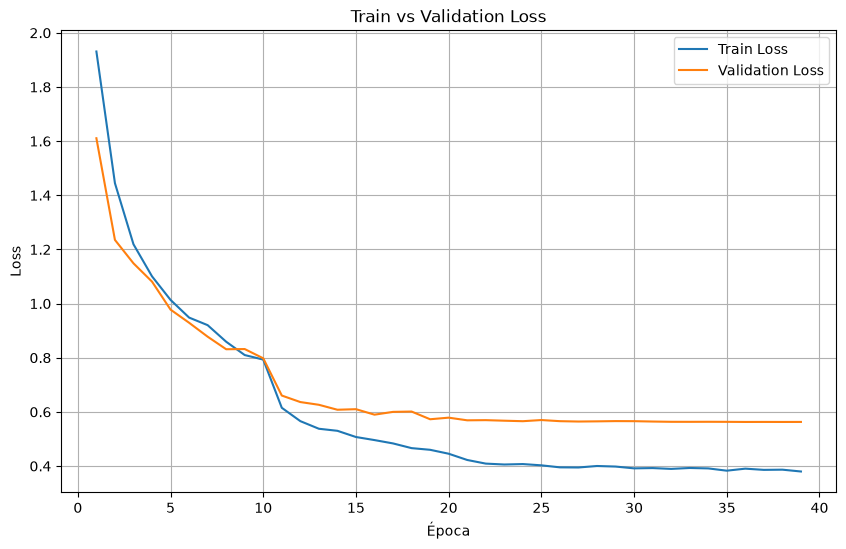

In [66]:
import matplotlib.pyplot as plt

epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    history["train_loss"],
    label="Train Loss"
)

plt.plot(
    epochs,
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")

plt.legend()
plt.grid()

plt.show()

## 10.2 Train/Validation Accuracy

Se visualizará la evolución de Accuracy durante el entrenamiento.

Accuracy representa la proporción de imágenes clasificadas
correctamente.

Se compararán:

- Train Accuracy.
- Validation Accuracy.

Un modelo que generaliza correctamente debería mostrar una mejora
progresiva de ambas métricas sin una separación excesiva entre ellas.

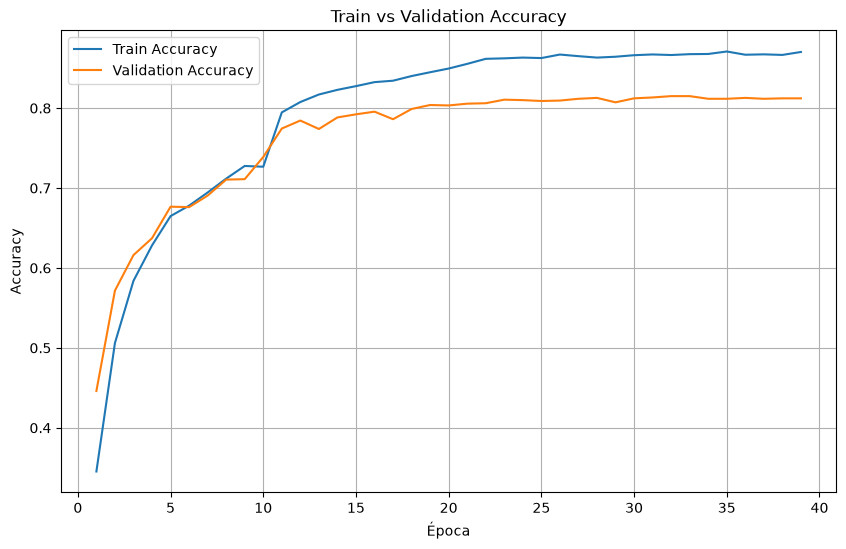

In [67]:
epochs = range(1, len(history["train_accuracy"]) + 1)

plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    history["train_accuracy"],
    label="Train Accuracy"
)

plt.plot(
    epochs,
    history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.title("Train vs Validation Accuracy")

plt.legend()
plt.grid()

plt.show()

## 10.3 Learning Rate

Se visualizará la evolución del Learning Rate durante el entrenamiento.

El scheduler StepLR reduce el Learning Rate periódicamente.

Esto permite utilizar pasos mayores durante las primeras etapas del
entrenamiento y pasos menores posteriormente.

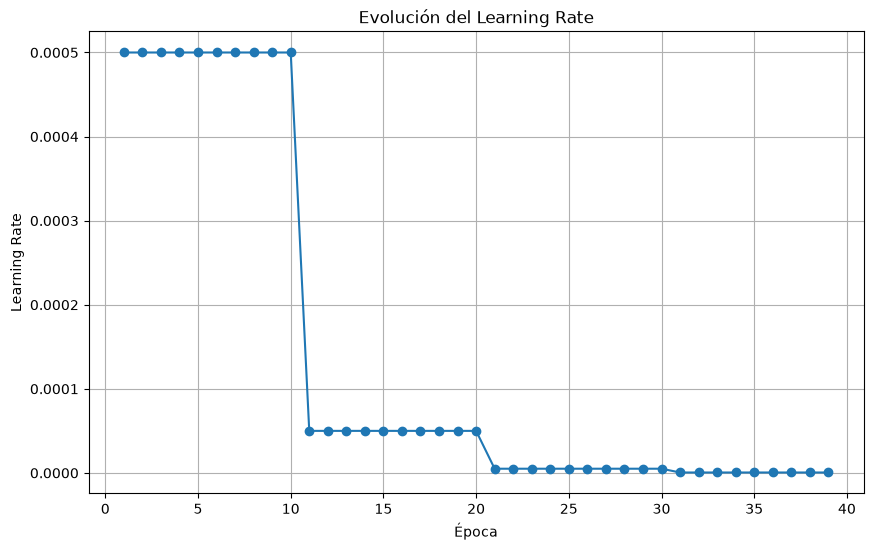

In [68]:
epochs = range(1, len(history["learning_rate"]) + 1)

plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    history["learning_rate"],
    marker="o"
)

plt.xlabel("Época")
plt.ylabel("Learning Rate")
plt.title("Evolución del Learning Rate")

plt.grid()

plt.show()

## 10.4 Interpretación

Las curvas obtenidas permiten analizar el comportamiento del Vision
Transformer durante el entrenamiento.

Se debe observar:

1. Si Train Loss disminuye.
2. Si Validation Loss disminuye.
3. Si Train Accuracy aumenta.
4. Si Validation Accuracy aumenta.
5. Si existe una separación significativa entre entrenamiento y
   validación.
6. El efecto de las reducciones del Learning Rate.
7. La época en la que se obtuvo el mejor modelo.

In [69]:
best_epoch = min(
    range(len(history["val_loss"])),
    key=lambda i: history["val_loss"][i]
)

print(
    f"Mejor época: {best_epoch + 1}"
)

print(
    f"Validation Loss: "
    f"{history['val_loss'][best_epoch]:.4f}"
)

print(
    f"Validation Accuracy: "
    f"{history['val_accuracy'][best_epoch] * 100:.2f}%"
)

Mejor época: 38
Validation Loss: 0.5628
Validation Accuracy: 81.22%


# 11. Evaluación

En esta sección se evaluará el Vision Transformer utilizando el conjunto
de test.

El conjunto de test no fue utilizado para actualizar los parámetros del
modelo ni para seleccionar el mejor modelo durante el entrenamiento.

Primero se cargarán los pesos correspondientes al mejor modelo obtenido
durante la validación.

Posteriormente se realizarán predicciones sobre todas las imágenes del
conjunto de test y se calcularán diferentes métricas:

- Accuracy.
- Precision.
- Recall.
- F1-Score.
- Matriz de Confusión.
- Classification Report.
- ROC/AUC.

In [70]:
torch.save(
    model.state_dict(),
    MODEL_PATH
)

## 11.1 Carga del mejor modelo

Se cargarán los parámetros correspondientes al mejor modelo obtenido
durante el entrenamiento.

De esta manera, la evaluación final utilizará el modelo que obtuvo el
mejor desempeño sobre el conjunto de validación.

In [71]:
# Cargar los mejores pesos
model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=device
    )
)

# Modo evaluación
model.eval()

print("Mejor modelo cargado correctamente.")

Mejor modelo cargado correctamente.


## 11.2 Predicciones

Se realizarán predicciones sobre todas las imágenes del conjunto de
test.

Para cada imagen se almacenará:

- La clase real.
- La clase predicha.

Estos valores serán utilizados posteriormente para calcular las
métricas de evaluación y construir la matriz de confusión.

In [72]:
import numpy as np

all_labels = []
all_predictions = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        logits, _ = model(images)

        predictions = torch.argmax(
            logits,
            dim=1
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

y_true = np.array(all_labels)
y_pred = np.array(all_predictions)

print("Número de muestras evaluadas:", len(y_true))

Número de muestras evaluadas: 1800


## 11.3 Accuracy

Accuracy representa la proporción de predicciones correctas respecto
al número total de muestras evaluadas.

Se calcula como:

Accuracy = predicciones correctas / total de predicciones

In [73]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_true,
    y_pred
)

print(
    f"Accuracy: {accuracy * 100:.2f}%"
)

Accuracy: 81.00%


## 11.4 Precision

Precision mide qué tan confiables son las predicciones positivas
realizadas por el modelo para cada clase.

En un problema multiclase se calculará utilizando el promedio
`weighted`, que tiene en cuenta la cantidad de muestras de cada clase.

In [74]:
from sklearn.metrics import precision_score

precision = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

print(
    f"Precision: {precision * 100:.2f}%"
)

Precision: 80.99%


## 11.5 Recall

Recall mide la capacidad del modelo para identificar correctamente
las muestras pertenecientes a cada clase.

Se utilizará el promedio `weighted` para obtener una métrica global
considerando el número de muestras de cada clase.

In [75]:
from sklearn.metrics import recall_score

recall = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

print(
    f"Recall: {recall * 100:.2f}%"
)

Recall: 81.00%


## 11.6 F1-Score

F1-Score combina Precision y Recall en una única métrica mediante su
media armónica.

Se utilizará `weighted` para considerar el número de muestras de cada
clase.

In [76]:
from sklearn.metrics import f1_score

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

print(
    f"F1-Score: {f1 * 100:.2f}%"
)

F1-Score: 80.90%


In [77]:
print("===== MÉTRICAS DEL VISION TRANSFORMER =====")

print(
    f"Accuracy : {accuracy * 100:.2f}%"
)

print(
    f"Precision: {precision * 100:.2f}%"
)

print(
    f"Recall   : {recall * 100:.2f}%"
)

print(
    f"F1-Score : {f1 * 100:.2f}%"
)

===== MÉTRICAS DEL VISION TRANSFORMER =====
Accuracy : 81.00%
Precision: 80.99%
Recall   : 81.00%
F1-Score : 80.90%


## 11.7 Matriz de Confusión

La matriz de confusión permitirá analizar las predicciones clase por
clase.

Las filas representan las clases reales y las columnas representan
las clases predichas.

Los valores de la diagonal principal representan las clasificaciones
correctas.

Los valores fuera de la diagonal representan errores de clasificación.

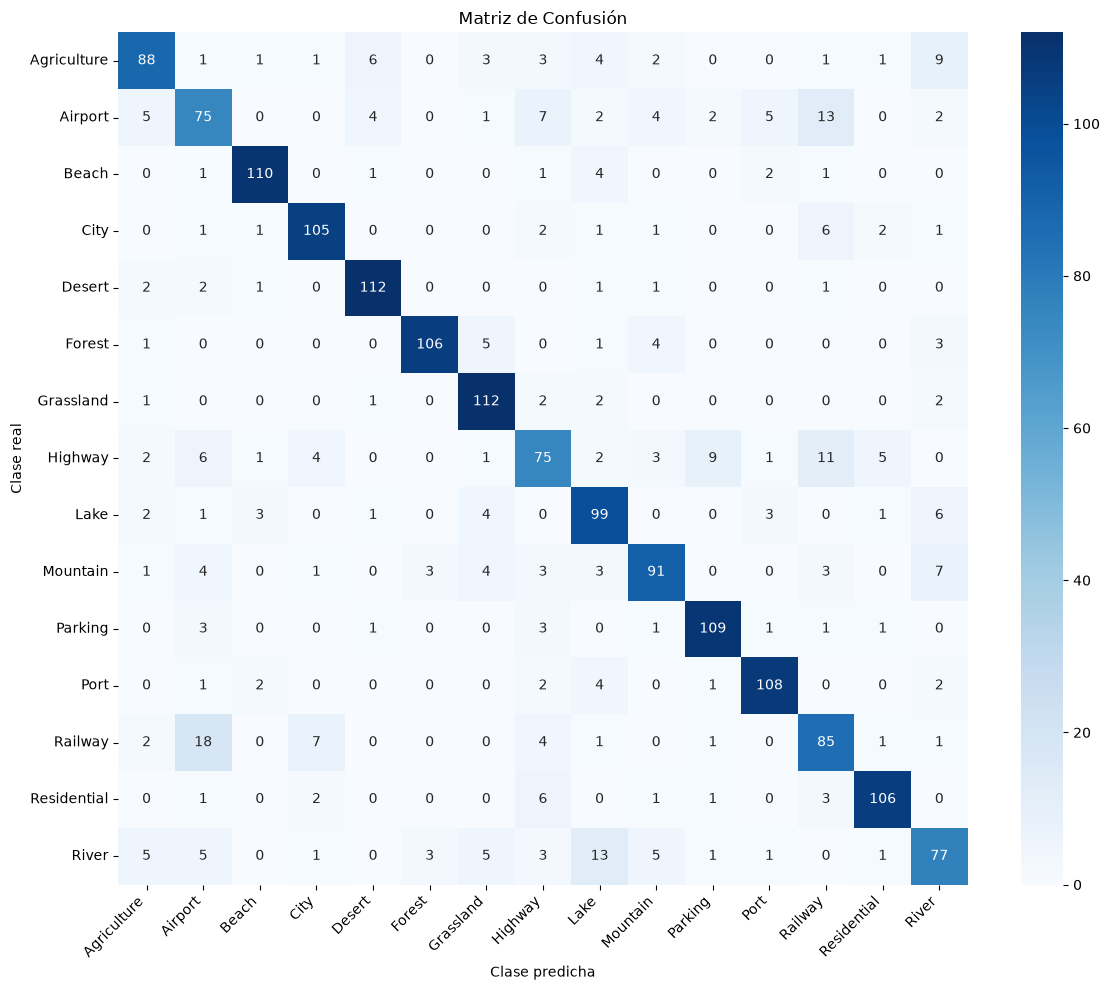

In [78]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Clase predicha")

plt.ylabel("Clase real")

plt.title("Matriz de Confusión")

plt.xticks(rotation=45, ha="right")

plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

## 11.8 Classification Report

Se generará un reporte detallado que mostrará Precision, Recall y
F1-Score para cada una de las 15 clases.

Esto permitirá analizar si el modelo funciona de manera uniforme
o si presenta dificultades particulares con determinadas clases.

In [79]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.81      0.73      0.77       120
           1       0.63      0.62      0.63       120
           2       0.92      0.92      0.92       120
           3       0.87      0.88      0.87       120
           4       0.89      0.93      0.91       120
           5       0.95      0.88      0.91       120
           6       0.83      0.93      0.88       120
           7       0.68      0.62      0.65       120
           8       0.72      0.82      0.77       120
           9       0.81      0.76      0.78       120
          10       0.88      0.91      0.89       120
          11       0.89      0.90      0.90       120
          12       0.68      0.71      0.69       120
          13       0.90      0.88      0.89       120
          14       0.70      0.64      0.67       120

    accuracy                           0.81      1800
   macro avg       0.81      0.81      0.81      1800
weighted avg       0.81   

## 11.9 ROC/AUC

Para calcular ROC/AUC en un problema multiclase se necesitan las
puntuaciones correspondientes a las diferentes clases.

El modelo produce logits para las 15 clases.

Estos logits serán transformados mediante Softmax para obtener
probabilidades.

Posteriormente se utilizará una estrategia One-vs-Rest para calcular
ROC/AUC multiclase.

In [80]:
from scipy.special import softmax

all_probabilities = []
all_labels_roc = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        logits, _ = model(images)

        probabilities = torch.softmax(
            logits,
            dim=1
        )

        all_probabilities.extend(
            probabilities.cpu().numpy()
        )

        all_labels_roc.extend(
            labels.numpy()
        )

y_prob = np.array(all_probabilities)
y_true_roc = np.array(all_labels_roc)

print("Probabilidades:")
print(y_prob.shape)

print("Etiquetas:")
print(y_true_roc.shape)

Probabilidades:
(1800, 15)
Etiquetas:
(1800,)


In [81]:
from sklearn.preprocessing import label_binarize

y_true_onehot = label_binarize(
    y_true_roc,
    classes=np.arange(NUM_CLASSES)
)

print(
    y_true_onehot.shape
)

(1800, 15)


In [82]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(
    y_true_onehot,
    y_prob,
    multi_class="ovr",
    average="weighted"
)

print(
    f"ROC-AUC: {roc_auc:.4f}"
)

ROC-AUC: 0.9837


In [83]:
fpr = {}
tpr = {}
roc_auc = {}

for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(
        y_true_onehot[:, i],
        y_prob[:, i]
    )

    roc_auc[i] = auc(
        fpr[i],
        tpr[i]
    )

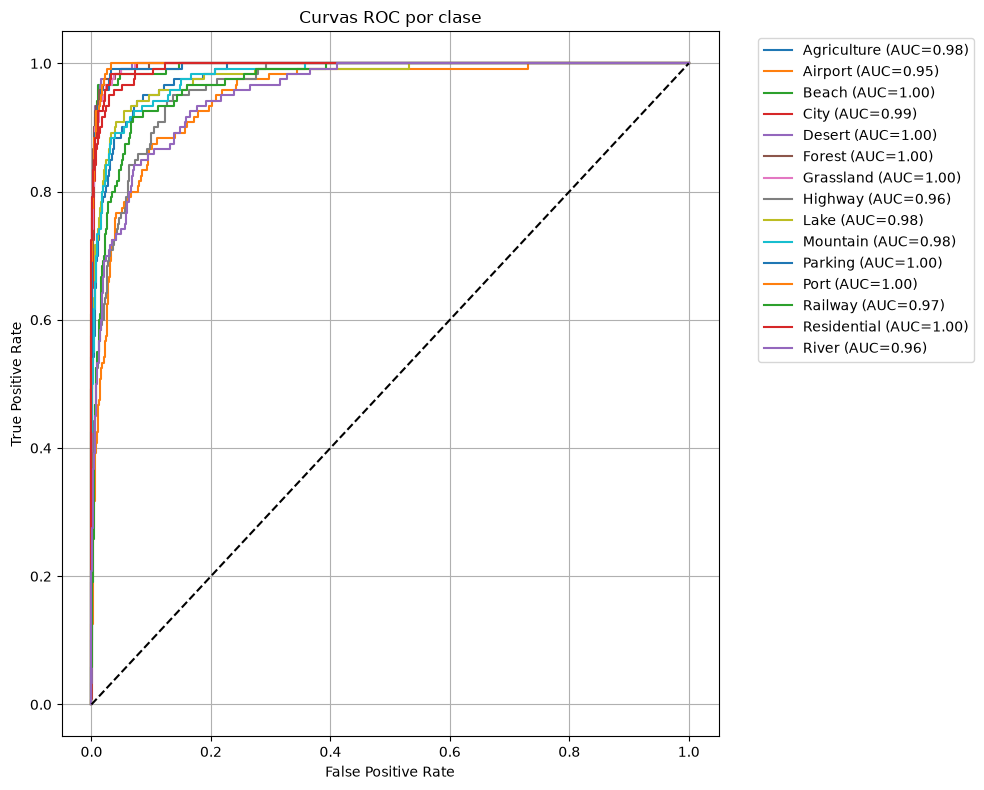

In [84]:
plt.figure(figsize=(10,8))

for i in range(len(classes)):
    plt.plot(
        fpr[i],
        tpr[i],
        label=f"{classes[i]} (AUC={roc_auc[i]:.2f})"
    )

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("Curvas ROC por clase")

plt.legend(
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.grid(True)

plt.tight_layout()

plt.show() 

### Resumen de métricas

Las métricas obtenidas sobre el conjunto de test serán utilizadas
posteriormente para comparar el rendimiento del Vision Transformer
con el modelo CNN desarrollado en el Laboratorio 2.

In [85]:
print("=" * 50)
print("      RESULTADOS FINALES - VISION TRANSFORMER")
print("=" * 50)

print(
    f"Accuracy   : {accuracy * 100:.2f}%"
)

print(
    f"Precision  : {precision * 100:.2f}%"
)

print(
    f"Recall     : {recall * 100:.2f}%"
)

print(
    f"F1-Score   : {f1 * 100:.2f}%"
)

print(
    f"ROC-AUC    : {roc_auc:.4f}"
)

print("=" * 50)

      RESULTADOS FINALES - VISION TRANSFORMER
Accuracy   : 81.00%
Precision  : 80.99%
Recall     : 81.00%
F1-Score   : 80.90%


TypeError: unsupported format string passed to dict.__format__

## 12.1 Carga del modelo CNN

Se reconstruirá la arquitectura CNN utilizada en el Laboratorio 2 y
se cargarán los pesos correspondientes al mejor modelo obtenido durante
el entrenamiento.

Posteriormente, el modelo será utilizado para realizar predicciones
sobre el mismo conjunto de test utilizado para evaluar el Vision
Transformer.

In [86]:
class SkyviewCNN(nn.Module):

    def __init__(self, num_classes=15):
        super().__init__()

        self.features = nn.Sequential(

            # Bloque 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Bloque 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Bloque 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x

In [87]:
cnn_model = SkyviewCNN(
    num_classes=15
).to(device)

In [88]:
import os

# Carpeta para guardar modelos

MODEL_DIR = "models"

os.makedirs(MODEL_DIR, exist_ok=True)

In [90]:
cnn_model = SkyviewCNN(
    num_classes=15
).to(device)

In [91]:
BEST_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "best_mlp_skyview.pth"
)
cnn_model.load_state_dict(
    torch.load(
        BEST_MODEL_PATH,
        map_location=device
    )
)

cnn_model.eval()

print("✓ Mejor modelo CNN cargado correctamente.")

✓ Mejor modelo CNN cargado correctamente.


In [92]:
cnn_history = {
    "train_loss": [...],
    "train_accuracy": [...],
    "val_loss": [...],
    "val_accuracy": [...],
    "learning_rate": [...]
}

In [93]:
def get_predictions(model, test_loader, device):

    model.eval()

    y_true = []
    y_pred = []
    y_prob = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            probabilities = torch.softmax(
                outputs,
                dim=1
            )

            _, predicted = torch.max(
                probabilities,
                dim=1
            )

            y_true.extend(
                labels.cpu().numpy()
            )

            y_pred.extend(
                predicted.cpu().numpy()
            )

            y_prob.extend(
                probabilities.cpu().numpy()
            )

    return (
        np.array(y_true),
        np.array(y_pred),
        np.array(y_prob)
    )

In [94]:
cnn_y_true, cnn_y_pred, cnn_y_prob = get_predictions(
    cnn_model,
    test_loader,
    device
)

print(
    "Muestras evaluadas:",
    len(cnn_y_true)
)

print(
    "Probabilidades:",
    cnn_y_prob.shape
)

Muestras evaluadas: 1800
Probabilidades: (1800, 15)


## 12.4 Métricas de evaluación de la CNN

La CNN será evaluada utilizando las mismas métricas utilizadas para
el Vision Transformer.

Esto permitirá realizar una comparación directa entre ambas
arquitecturas.

Las métricas serán:

- Accuracy.
- Precision.
- Recall.
- F1-Score.
- ROC-AUC.

In [95]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [96]:
cnn_accuracy = accuracy_score(
    cnn_y_true,
    cnn_y_pred
)

In [97]:
cnn_precision = precision_score(
    cnn_y_true,
    cnn_y_pred,
    average="weighted",
    zero_division=0
)

In [98]:
cnn_recall = recall_score(
    cnn_y_true,
    cnn_y_pred,
    average="weighted",
    zero_division=0
)

In [99]:
cnn_f1 = f1_score(
    cnn_y_true,
    cnn_y_pred,
    average="weighted",
    zero_division=0
)

In [100]:
from sklearn.preprocessing import label_binarize

cnn_y_true_onehot = label_binarize(
    cnn_y_true,
    classes=np.arange(NUM_CLASSES)
)

In [101]:
cnn_roc_auc = roc_auc_score(
    cnn_y_true_onehot,
    cnn_y_prob,
    multi_class="ovr",
    average="weighted"
)

In [102]:
print("=" * 50)
print("        RESULTADOS FINALES - CNN")
print("=" * 50)

print(
    f"Accuracy   : {cnn_accuracy * 100:.2f}%"
)

print(
    f"Precision  : {cnn_precision * 100:.2f}%"
)

print(
    f"Recall     : {cnn_recall * 100:.2f}%"
)

print(
    f"F1-Score   : {cnn_f1 * 100:.2f}%"
)

print(
    f"ROC-AUC    : {cnn_roc_auc:.4f}"
)

print("=" * 50)

        RESULTADOS FINALES - CNN
Accuracy   : 49.22%
Precision  : 54.90%
Recall     : 49.22%
F1-Score   : 44.38%
ROC-AUC    : 0.8788


In [103]:
transformer_accuracy = accuracy
transformer_precision = precision
transformer_recall = recall
transformer_f1 = f1
transformer_roc_auc = roc_auc

In [104]:
import pandas as pd

comparison_metrics = pd.DataFrame({

    "Métrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],

    "CNN": [
        cnn_accuracy,
        cnn_precision,
        cnn_recall,
        cnn_f1,
        cnn_roc_auc
    ],

    "Vision Transformer": [
        transformer_accuracy,
        transformer_precision,
        transformer_recall,
        transformer_f1,
        transformer_roc_auc
    ]
})

comparison_metrics

,Métrica,CNN,Vision Transformer
0,Accuracy,0.492222,0.81
1,Precision,0.549048,0.809879
2,Recall,0.492222,0.81
3,F1-Score,0.443809,0.809043
4,ROC-AUC,0.878837,"{0: 0.9817609126984127, 1: 0.9516617063492063,..."


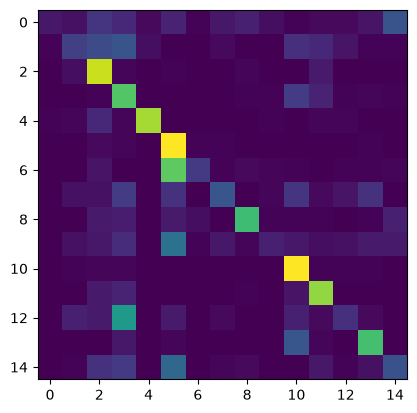

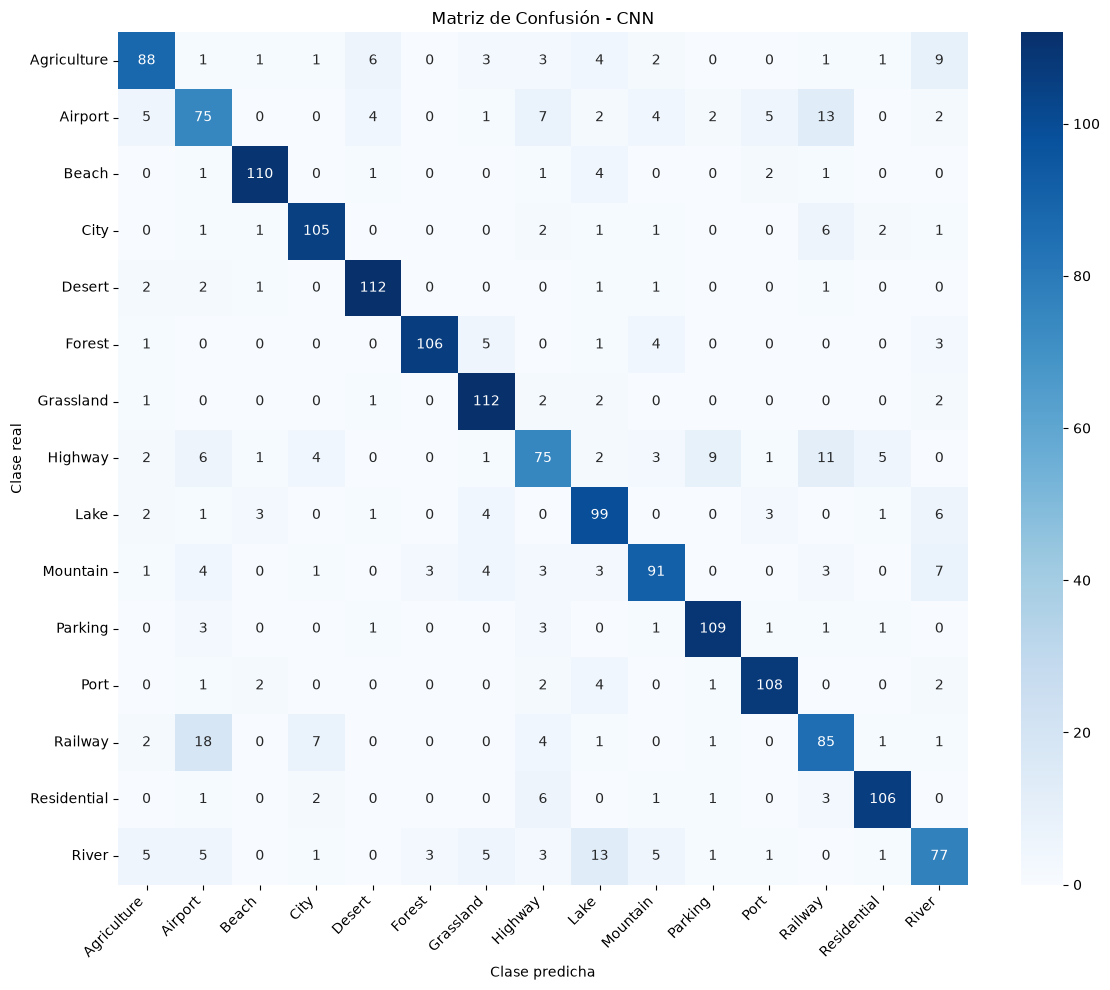

In [ ]:
from sklearn.metrics import confusion_matrix

cnn_cm = confusion_matrix(
    cnn_y_true,
    cnn_y_pred
)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Clase predicha")

plt.ylabel("Clase real")

plt.title("Matriz de Confusión - CNN")

plt.xticks(rotation=45, ha="right")

plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

In [106]:
from sklearn.metrics import classification_report

print(
    classification_report(
        cnn_y_true,
        cnn_y_pred,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.78      0.06      0.11       120
           1       0.39      0.17      0.24       120
           2       0.46      0.86      0.60       120
           3       0.30      0.68      0.42       120
           4       0.93      0.81      0.87       120
           5       0.35      0.93      0.51       120
           6       0.73      0.16      0.26       120
           7       0.56      0.25      0.34       120
           8       0.78      0.64      0.70       120
           9       0.48      0.08      0.14       120
          10       0.51      0.93      0.66       120
          11       0.62      0.78      0.69       120
          12       0.37      0.12      0.19       120
          13       0.64      0.66      0.65       120
          14       0.35      0.23      0.28       120

    accuracy                           0.49      1800
   macro avg       0.55      0.49      0.44      1800
weighted avg       0.55   

In [110]:
from sklearn.metrics import confusion_matrix

cm_cnn = confusion_matrix(
    cnn_y_true,
    cnn_y_pred
)

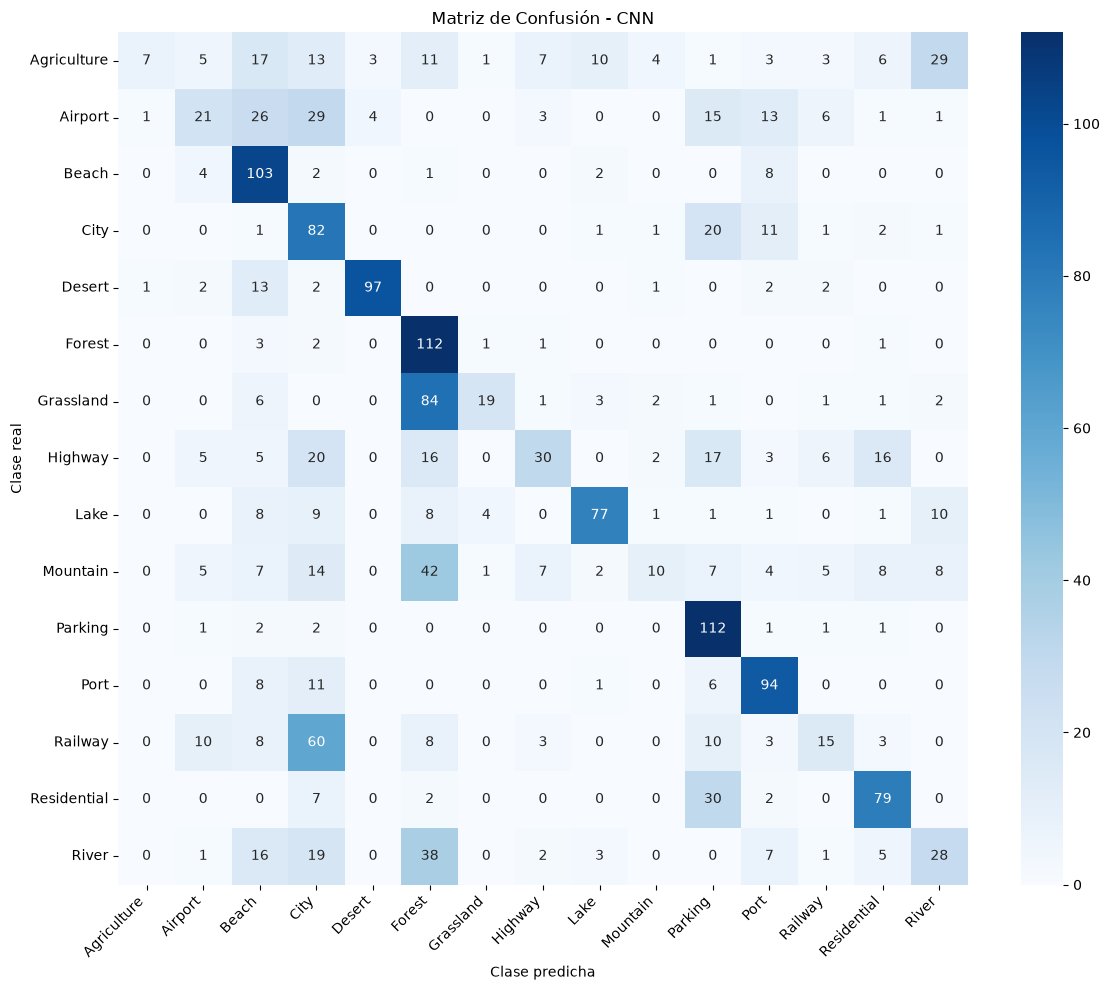

In [111]:
plt.figure(figsize=(12,10))

sns.heatmap(
    cm_cnn,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Clase predicha")
plt.ylabel("Clase real")
plt.title("Matriz de Confusión - CNN")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [112]:
cm_transformer = confusion_matrix(
    y_true,
    y_pred
)

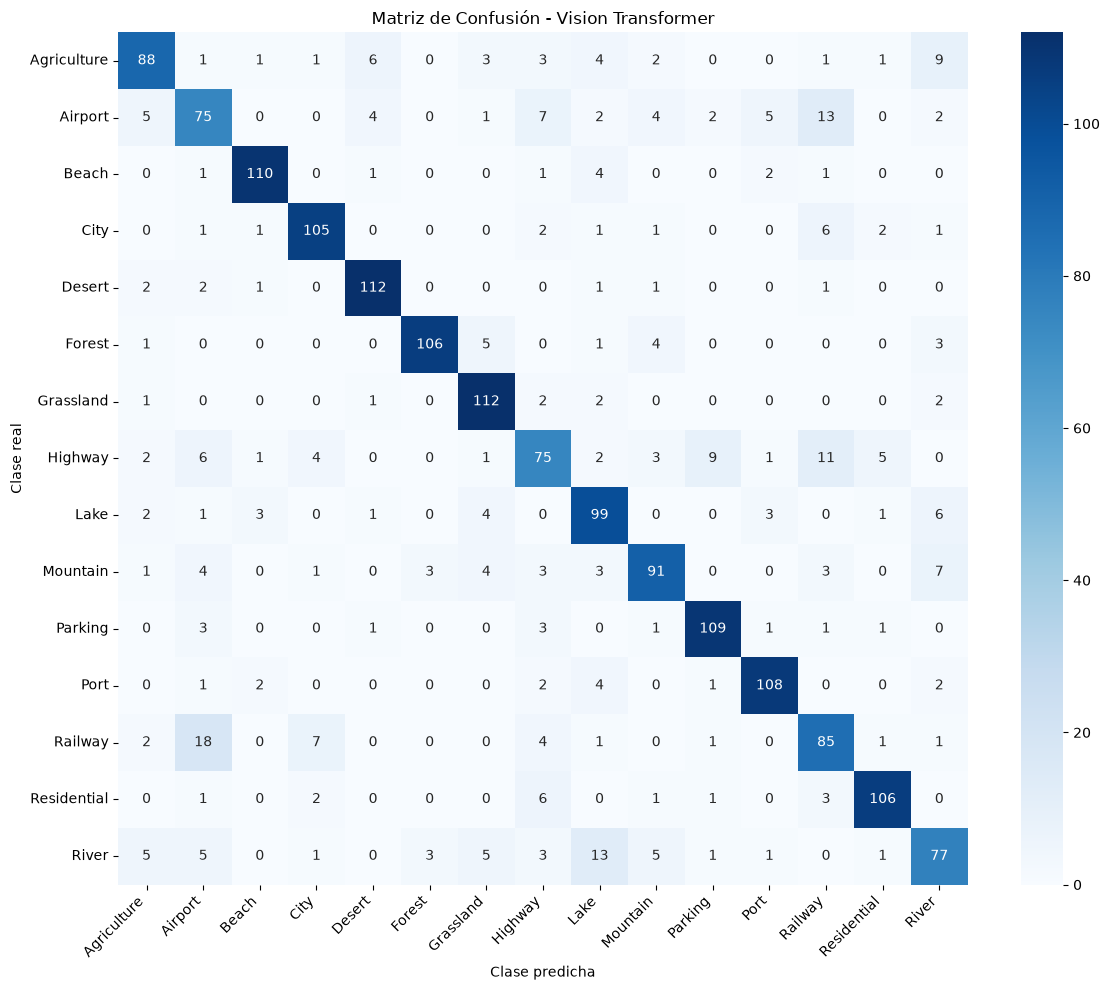

In [113]:
plt.figure(figsize=(12,10))

sns.heatmap(
    cm_transformer,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Clase predicha")
plt.ylabel("Clase real")
plt.title("Matriz de Confusión - Vision Transformer")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

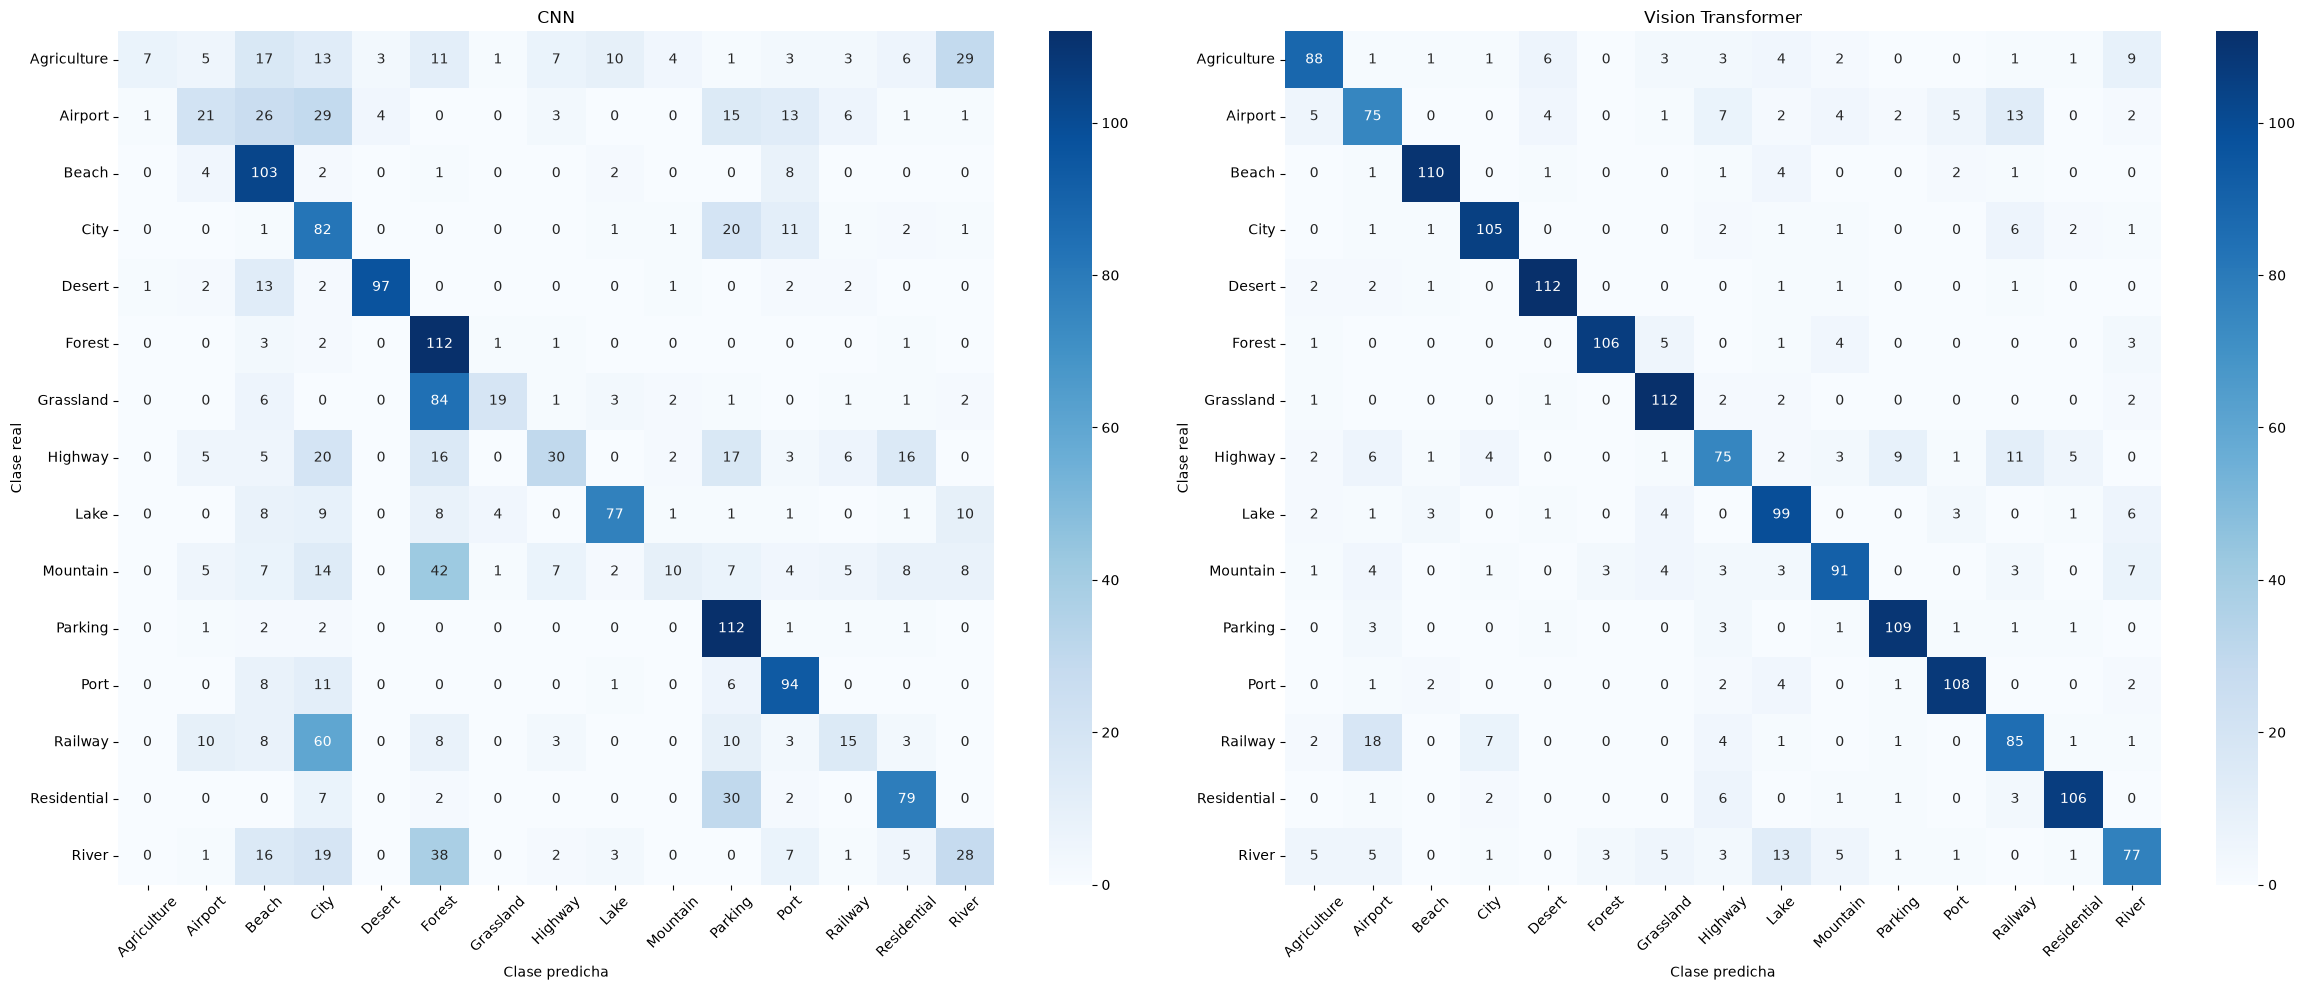

In [114]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(24, 10)
)

# CNN
sns.heatmap(
    cm_cnn,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes,
    ax=axes[0]
)

axes[0].set_xlabel("Clase predicha")
axes[0].set_ylabel("Clase real")
axes[0].set_title("CNN")

axes[0].tick_params(
    axis="x",
    rotation=45
)

axes[0].tick_params(
    axis="y",
    rotation=0
)


# Transformer
sns.heatmap(
    cm_transformer,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes,
    ax=axes[1]
)

axes[1].set_xlabel("Clase predicha")
axes[1].set_ylabel("Clase real")
axes[1].set_title("Vision Transformer")

axes[1].tick_params(
    axis="x",
    rotation=45
)

axes[1].tick_params(
    axis="y",
    rotation=0
)

plt.tight_layout()
plt.show()

In [115]:
training_comparison = pd.DataFrame({

    "Característica": [
        "Épocas ejecutadas",
        "Mejor Validation Loss",
        "Mejor Validation Accuracy",
        "Época mejor Validation Loss",
        "Tiempo de entrenamiento (min)"
    ],

    "CNN": [
        57,
        0.8343,
        0.7567,
        47,
        563.02
    ],

    "Vision Transformer": [
        len(history["train_loss"]),
        min(history["val_loss"]),
        max(history["val_accuracy"]),
        np.argmin(history["val_loss"]) + 1,
        None
    ]
})

training_comparison

,Característica,CNN,Vision Transformer
0,Épocas ejecutadas,57.0000,39.000000
1,Mejor Validation Loss,0.8343,0.562846
2,Mejor Validation Accuracy,0.7567,0.815000
3,Época mejor Validation Loss,47.0000,38.000000
4,Tiempo de entrenamiento (min),563.0200,NaN
